# Прогнозирование оттока клиентов на примере данных телекоммуникацонной компании



Рассмотрим набор данных от телекоммуникационной компании. В данных содержится информация о клиентах и услугах, которыми они пользуются, длительности пользования услугами оператора, методе оплаты, размере оплаты.

Необходимо проанализировать данные и спрогнозировать отток клиентов (выявить лояльных пользователей и тех, которые не продлят договор и уйдут).

В современном мире, где конкуренция между компаниями становится все более жесткой, понимание поведения клиентов и их удержание становятся ключевыми факторами для успешного бизнеса. Одним из важных инструментов в достижении этой цели является анализ данных клиентов и прогнозирование оттока пользователей.

**Анализ данных клиентов** – это процесс извлечения, очистки, исследования и визуализации данных о клиентах компании с целью выявления интересных закономерностей и паттернов в их поведении. Такой анализ позволяет компаниям понять, что делает их клиентов довольными, что их раздражает и, самое главное, предсказать вероятность того, что клиент может уйти к конкуренту, что называется оттоком пользователей.

**Прогнозирование оттока** – это процесс разработки моделей машинного обучения, которые позволяют предсказать, сколько и какие клиенты вероятно покинут компанию в определенный период времени. Предупреждение о возможном оттоке дает компаниям возможность принять меры по удержанию клиентов, что может существенно снизить потери и повысить общую прибыль.


Устанавливаем дополнительные библиотеки

In [1]:
%pip install seaborn imblearn scikit-image category_encoders

Defaulting to user installation because normal site-packages is not writeable
  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached scikit_image-0.24.0-cp39-cp39-macosx_12_0_arm64.whl.metadata (14 kB)
  Using cached imageio-2.37.2-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2024.8.30-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached scikit_image-0.24.0-cp39-cp39-macosx_12_0_arm64.whl (13.4 MB)
Using cached imageio-2.37.2-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached tifffile-2024.8.30-py3-none-any.whl (227 kB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is avail

In [2]:
# импортируем 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import category_encoders as ce
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from imblearn.over_sampling import SMOTE # бибилотека для расбалнсированных классов (ML)
from sklearn.ensemble import RandomForestClassifier

/Users/bereznevn/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(



# Загрузка данных 


In [3]:
# Загружаем данные в DataFrame:-
df=pd.read_csv("Datasets/Customer_Churn.csv");

In [4]:
#посмотреть данные
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Структура данных
Customer_Churn.csv
- customerID – id клиента
- gender – пол клиента (male/female)
- SeniorCitizen – яляется ли клиент пенсионером (1, 0)
- Partner – состоит ли клиент в браке (Yes, No)
- Dependents – есть ли у клиента иждивенцы (Yes, No)
- tenure – сколько месяцев человек являлся клиентом компании
- PhoneService – подключена ли услуга телефонной связи (Yes, No)
- MultipleLines – подключены ли несколько телефонных линий (Yes, No, No phone service)
- InternetService – интернет-провайдер клиента (DSL, Fiber optic, No)
- OnlineSecurity – подключена ли услуга онлайн-безопасности (Yes, No, No internet service)
- OnlineBackup – подключена ли услуга online backup (Yes, No, No internet service)
- DeviceProtection – есть ли у клиента страховка оборудования (Yes, No, No internet service)
- TechSupport – подключена ли услуга технической поддержки (Yes, No, No internet service)
- StreamingTV – подключена ли услуга стримингового телевидения (Yes, No, No internet service)
- StreamingMovies – подключена ли услуга стримингового кинотеатра (Yes, No, No internet service)
- Contract – тип контракта клиента (Month-to-month, One year, Two year)
- PaperlessBilling – пользуется ли клиент безбумажным биллингом (Yes, No)
- PaymentMethod – метод оплаты (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- MonthlyCharges – месячный размер оплаты на настоящий момент
- TotalCharges – общая сумма, которую клиент заплатил за услуги за все время
- Churn – произошел ли отток (Yes or No) 

In [5]:
# sample=df.sample(5); 
# print(sample);

In [6]:

# В Dataframe сразу видно, что customerID бесполезный признак, поэтому удаляем customerID:-

df.drop("customerID",axis="columns",inplace=True);

df.dtypes


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
# Надо сделать преобразование типов TotalCharges: из "object" в числовой тип

df["TotalCharges"].values # значения типа  "string"
df["MonthlyCharges"].values #  -> "int"



array([ 29.85,  56.95,  53.85, ...,  29.6 ,  74.4 , 105.65])

In [8]:

# конвертируем тип TotalCharges в числовой:-

pd.to_numeric(df["TotalCharges"], errors="coerce")

# Приведенная выше функция преобразует его в числовое значение и если есть значения NAN, эти значения не учитываются


# извлекаем строки с пустым TotalCharges -> NULL
df1=df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]
df1.shape # -> осталось 11 строк с NULL 

(11, 20)

In [9]:
df2=df[df.TotalCharges!=" "]

df2.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [10]:
df2.tail()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [11]:
df2.TotalCharges=pd.to_numeric(df2.TotalCharges)
#df2.loc[:,"TotalCharges"]=pd.to_numeric(df2.TotalCharges)
# проверяем NULL значения (пропуски в данных) во всем датасете
df2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/3252013984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.TotalCharges=pd.to_numeric(df2.TotalCharges)


### Анализ оттока:-

### Churn -> No[Остается], Yes[Уходит от провайдера]

Text(0.5, 1.0, 'Анализ оттока по признаку Tenure')

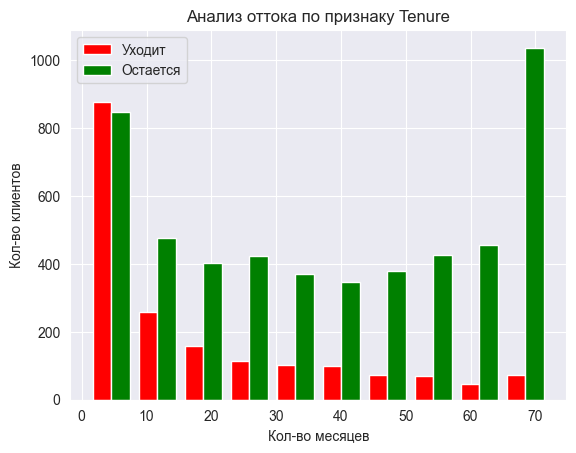

In [12]:

tenure_churn_no=df2[df2["Churn"]=="No"].tenure # остается

tenure_churn_yes=df2[df2["Churn"]=="Yes"].tenure # уходит

plt.hist([tenure_churn_yes, tenure_churn_no], color=["red", "green"], label=["Уходит", "Остается"])
plt.legend()
plt.xlabel("Кол-во месяцев")
plt.ylabel("Кол-во клиентов")
plt.title("Анализ оттока по признаку Tenure")

Из приведенного выше графика ясно, что клиенты со сроком контракта более 50 месяцев имеют меньшюю вероятность оттока 
от компании, в то время как клиенты со сроком контракта менее 10 месяцев с большей вероятностью уйдут от компании


Text(0.5, 1.0, 'Анализ оттока по признаку Monthly Charges')

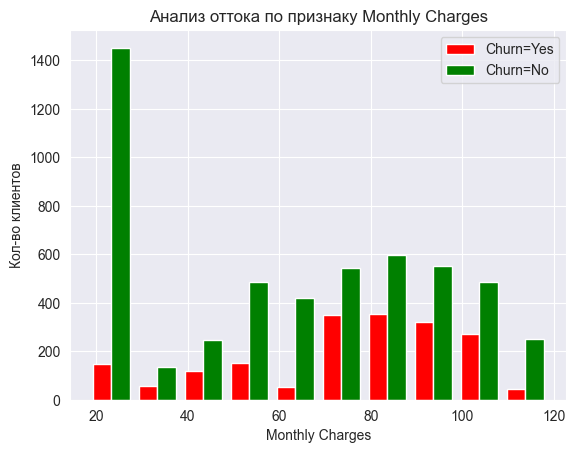

In [13]:
MonthlyCharges_churn_no=df2[df2["Churn"]=="No"].MonthlyCharges # клиенты не уходят от компании

MonthlyCharges_churn_yes=df2[df2["Churn"]=="Yes"].MonthlyCharges # клиенты уходят от компании

plt.hist([MonthlyCharges_churn_yes, MonthlyCharges_churn_no], color=["red", "green"], label=["Churn=Yes", "Churn=No"])
plt.legend()
plt.xlabel("Monthly Charges")
plt.ylabel("Кол-во клиентов")
plt.title("Анализ оттока по признаку Monthly Charges")

Из приведенного выше графика видно, что клиенты с низкими и с высокими ежемесячными платежами не покидают компанию, а клиенты, которые ежемесячно платят около 70-100 долларов, имеют вероятнось около 0,5 покинуть компанию

In [14]:
# распечатаем уникальные значения в каждом столбце
for column in df2:
    print(column , df2[column].unique())

def print_unique_col_values(df):
   for column in df:
       if df[column].dtypes=="object":
               print(column, df[column].unique())
        
print_unique_col_values(df2);


gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges [  29.85 1889.5   

In [15]:
# заменим строковые значения "No internet service" и "No phone service" на строку "No":-
# pd.options.mode.copy_on_write = True

df2.replace("No internet service", "No", inplace=True);
df2.replace("No phone service", "No", inplace=True);

print_unique_col_values(df2);


gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['No' 'Yes']
StreamingTV ['No' 'Yes']
StreamingMovies ['No' 'Yes']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/1629916719.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.replace("No internet service", "No", inplace=True);
/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/1629916719.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.replace("No phone service", "No", inplace=True);


In [16]:
# проанализируем все столбцы со значениями "Yes" (или) "No":-
# Т.к. ML -алгоритмы не работают с категориальными значениями, заменим "Yes" и "No" на 1 и 0
# "Not leaving the company" -> 0 и "Leaving the company" -> 1. 

yes_no_columns=["Partner", "Dependents", "PhoneService", "MultipleLines", "OnlineSecurity",
"OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "PaperlessBilling", "Churn"]

for col in yes_no_columns:
    df2[col].replace({"Yes":1, "No":0}, inplace=True);

/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/2406334361.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2[col].replace({"Yes":1, "No":0}, inplace=True);
/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/2406334361.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', Tr

In [17]:
for col in yes_no_columns:
    df2[col].astype("int64");

In [18]:
df3=pd.get_dummies(data=df2, columns=["InternetService", "Contract", "PaymentMethod"],dtype="int64");    
df3.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [19]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   object 
 1   SeniorCitizen                            7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   MultipleLines                            7032 non-null   int64  
 7   OnlineSecurity                           7032 non-null   int64  
 8   OnlineBackup                             7032 non-null   int64  
 9   DeviceProtection                         7032 non-null   int64  
 10  TechSupport                              7032 non-nul

In [20]:
df2.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [21]:
# Также заменим Male = 0, Female = 1

df3.replace({"Male":0, "Female":1}, inplace=True); 
# df3.gender.astype("int64")
df3.dtypes #Теперь все значения числового типа

/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/2892507122.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3.replace({"Male":0, "Female":1}, inplace=True);


gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No             

In [22]:
df3.gender.tail()

7038    0
7039    1
7040    1
7041    0
7042    0
Name: gender, dtype: int64

In [23]:
# Преобразование данных (масштабирование):
# Признаки tenure, MonthlyCharges и TotalCharges масштабируем в [0,1]:

cols_to_scale=["tenure", "MonthlyCharges", "TotalCharges"];
scaler=MinMaxScaler() # создаем объект MinMaxScaler
     
df4=df3.copy();
df4[cols_to_scale]=scaler.fit_transform(df4[cols_to_scale]);

In [24]:
# разбиваем датасет на две части  train и  test:

X=df4.drop("Churn", axis="columns");
y=df4["Churn"];

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5);


#### Алгоритмы классификации классического машинного обучения

In [25]:
# Случайный лес - RandomForest Classifier #

rfc=RandomForestClassifier(n_estimators=100, n_jobs=-1, verbose=2, criterion="entropy");
rfc.fit(X_train, y_train);

print("Accuracy = ", accuracy_score(y_test, rfc.predict(X_test)));


building tree 1 of 100building tree 2 of 100
building tree 3 of 100

building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.0s


building tree 78 of 100building tree 79 of 100

building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85 of 100
building tree 86 of 100
building tree 87 of 100
building tree 88 of 100
building tree 89 of 100
building tree 90 of 100
building tree 91 of 100
building tree 92 of 100
building tree 93 of 100
building tree 94 of 100
building tree 95 of 100
building tree 96 of 100
building tree 97 of 100
building tree 98 of 100
building tree 99 of 100
building tree 100 of 100


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s


Accuracy =  0.7803837953091685


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [26]:
### К- ближ.соседей - KNN ###
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=3 , n_jobs=-1);
knn.fit(X_train, y_train);

print("Accuracy = ", accuracy_score(y_test, knn.predict(X_test)));

Accuracy =  0.7398720682302772


# Нейронная сеть
## Задание 1. 
Построить нейросетевую модель, обучить, оценить качество модели.

В этом задании необходимо использовать **Sequential** API для Tensorflow и Pytorch

1.Tensorflow

In [27]:
# Пример построения модели с помощью `Sequential` API 
model = tf.keras.models.Sequential()
model.add(tf.keras.Input(shape=(16,)))
# Input_shape тензор (batch_size, input_dim)
model.add(tf.keras.layers.Dense(32, activation='relu'))

# Модель ждет на вход тензор (None, 16)
# а на выходе будет (None, 32).
# После первого слоя не надо указывать входы для последующих слоев
model.add(tf.keras.layers.Dense(32))
model.output_shape


(None, 32)

In [28]:
# Постройте простую ИНС - MLP (Keras Tensorflow):


model=Sequential()
# Архитектура сети
#первым аргументом у Dense() идет кол-во выходных нейронов слоя
units = 26
model.add(Dense(units, input_dim = X_train.shape[1], activation = 'relu', kernel_initializer = tf.keras.initializers.HeNormal()))
model.add(Dense(8,activation = 'relu', kernel_initializer = tf.keras.initializers.HeNormal()))
model.add(Dense(8,activation = 'relu', kernel_initializer = tf.keras.initializers.HeNormal()))
model.add(Dense(1,activation = 'sigmoid', kernel_initializer = tf.keras.initializers.HeNormal()))

# Создаем модель
model.compile(optimizer='sgd', loss = "binary_crossentropy", metrics = ["accuracy"])



/Users/bereznevn/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# Обучение сети - метод fit
model.fit(X_train, y_train, epochs = 100)

# прямой проход сети - метод predict
test = [round(x[0]) for x in model.predict(X_test)];
print(accuracy_score(y_test, test)); #  accuracy на train

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - accuracy: 0.4685 - loss: 0.7712
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 376us/step - accuracy: 0.7471 - loss: 0.5881
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step - accuracy: 0.7349 - loss: 0.5796
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - accuracy: 0.7529 - loss: 0.5461
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.7389 - loss: 0.5401
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - accuracy: 0.7405 - loss: 0.5115
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - accuracy: 0.7369 - loss: 0.4940
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step - accuracy: 0.7529 - loss: 0.4723
Epoch 9/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - accuracy: 0.7824 - loss: 0.4504
Epoch 10/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.7852 - loss: 0.4466
Epoch 11/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.7928 - loss: 0.4330
Epoch 12/100
176/17

In [30]:
print(classification_report(y_test, test));

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       999
           1       0.67      0.57      0.62       408

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.79      0.80      0.79      1407



Из приведенного выше видно, что модель не очень хорошо работает для класса 1, т.е. для случая, когда клиенты уходят от
компании. Чтобы преодолеть эту проблему,  будем использовать метод SMOTE, но уже на 2-м наборе данных.

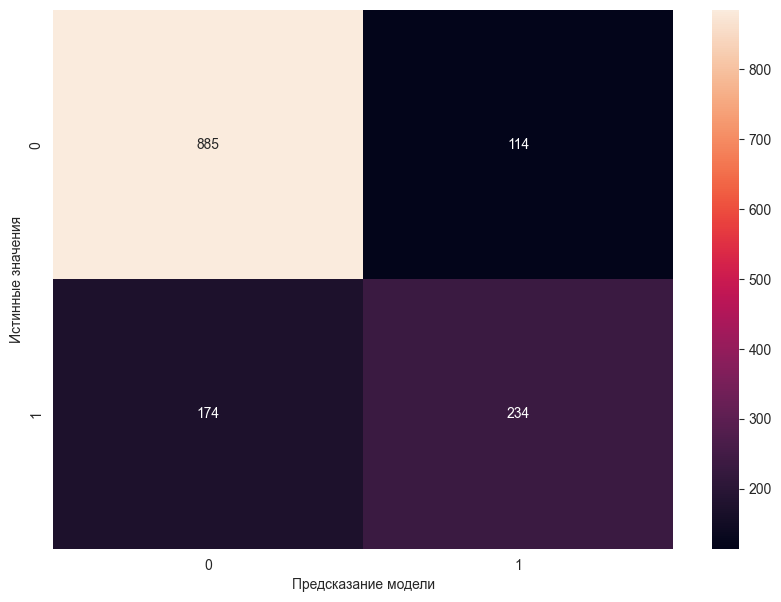

In [31]:
# Матрица ошибок - Confusion Matrix:

cm=tf.math.confusion_matrix(labels=y_test, predictions=test);

plt.figure(figsize=(10,7));
sns.heatmap(cm, annot=True, fmt="d");
plt.xlabel("Предсказание модели");
plt.ylabel("Истинные значения");

2. Pytorch

In [32]:
# Постройте простую ИНС - MLP (Pytorch):-
import torch
import torch.nn as nn
import torch.optim as optim

# Подготовка данных для Pytorch
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Архитектура MLP
model = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 26),
    nn.ReLU(),
    nn.Linear(26, 8),
    nn.ReLU(),
    nn.Linear(8, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Обучение
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

# Оценка
model.eval()
with torch.no_grad():
    y_pred_proba = model(X_test_t)
    y_pred = (y_pred_proba >= 0.5).int().squeeze(1)

test = y_pred.numpy()
print("Accuracy =", accuracy_score(y_test, test))
print(classification_report(y_test, test))

Accuracy = 0.6282871357498223
              precision    recall  f1-score   support

           0       0.70      0.84      0.76       999
           1       0.22      0.12      0.15       408

    accuracy                           0.63      1407
   macro avg       0.46      0.48      0.46      1407
weighted avg       0.56      0.63      0.59      1407



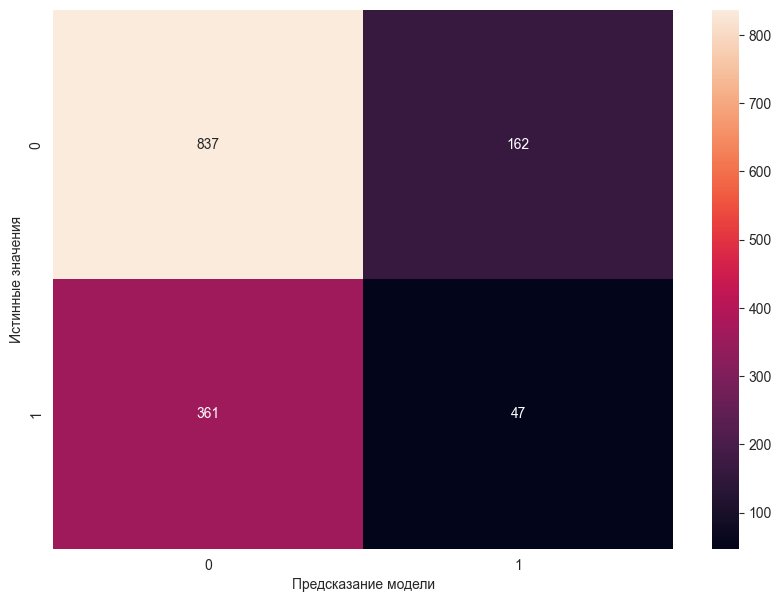

In [33]:
# Постройте матрицу ошибок - Confusion Matrix:-

from torcheval.metrics.functional import binary_confusion_matrix

y_pred_t = torch.tensor(test, dtype=torch.int64)
y_true_t = torch.tensor(y_test.values, dtype=torch.int64)
cm = binary_confusion_matrix(y_pred_t, y_true_t)

plt.figure(figsize=(10, 7))
sns.heatmap(cm.numpy(), annot=True, fmt="d")
plt.xlabel("Предсказание модели")
plt.ylabel("Истинные значения")
plt.show()


##  Рассмотрим один из подходов для работы с несбалансированными данными. 
## Второй датасет ( загрузить из папки Datasets)



In [34]:
# # Импорт наборов данных для обучения и тестирования:-
# # Датафрейм тестовых данных test предназначен только для инференса, чтобы найти целевое значение.
train=pd.read_csv("Datasets/train.csv");
test=pd.read_csv("Datasets/test.csv");


In [35]:
# Список столбцов:
train.columns

Index(['state', 'account_length', 'area_code', 'international_plan',
       'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes',
       'total_day_calls', 'total_day_charge', 'total_eve_minutes',
       'total_eve_calls', 'total_eve_charge', 'total_night_minutes',
       'total_night_calls', 'total_night_charge', 'total_intl_minutes',
       'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls', 'churn'],
      dtype='object')

In [36]:
# размеры DataFrame:
print(train.shape);

(4250, 20)


In [37]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   state                          4250 non-null   object 
 1   account_length                 4250 non-null   int64  
 2   area_code                      4250 non-null   object 
 3   international_plan             4250 non-null   object 
 4   voice_mail_plan                4250 non-null   object 
 5   number_vmail_messages          4250 non-null   int64  
 6   total_day_minutes              4250 non-null   float64
 7   total_day_calls                4250 non-null   int64  
 8   total_day_charge               4250 non-null   float64
 9   total_eve_minutes              4250 non-null   float64
 10  total_eve_calls                4250 non-null   int64  
 11  total_eve_charge               4250 non-null   float64
 12  total_night_minutes            4250 non-null   f

In [38]:
train.describe()

,account_length,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls
count,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000,4250.000000
mean,100.236235,7.631765,180.259600,99.907294,30.644682,200.173906,100.176471,17.015012,200.527882,99.839529,9.023892,10.256071,4.426353,2.769654,1.559059
std,39.698401,13.439882,54.012373,19.850817,9.182096,50.249518,19.908591,4.271212,50.353548,20.093220,2.265922,2.760102,2.463069,0.745204,1.311434
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,0.000000,143.325000,87.000000,24.365000,165.925000,87.000000,14.102500,167.225000,86.000000,7.522500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,0.000000,180.450000,100.000000,30.680000,200.700000,100.000000,17.060000,200.450000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,16.000000,216.200000,113.000000,36.750000,233.775000,114.000000,19.867500,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000
max,243.000000,52.000000,351.500000,165.000000,59.760000,359.300000,170.000000,30.540000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


## АНАЛИЗ ДАННЫХ ##

#### Одномерный анализ

Одномерный анализ — это, пожалуй, самая простая форма статистического анализа. Как и другие формы статистики, она может быть логической или описательной. Ключевым фактом является то, что задействована только одна переменная.

In [39]:
## Категориальные переменные ##:
# Создадим выборку всех категориальных признаков
categorical_variables=[];
categorical_variables=[feature for feature in train.columns if train[feature].dtype=="O"];

# Функция для вычисления процента для каждого признака:
def calculate_percentage(total, ax):
    for patch in ax.patches:
        percentage="{}%".format(round(100*(patch.get_height()/total),1));
        x=patch.get_x()+(patch.get_width()/2);
        y=patch.get_height();
        ax.annotate(percentage, (x, y), ha="center");
    

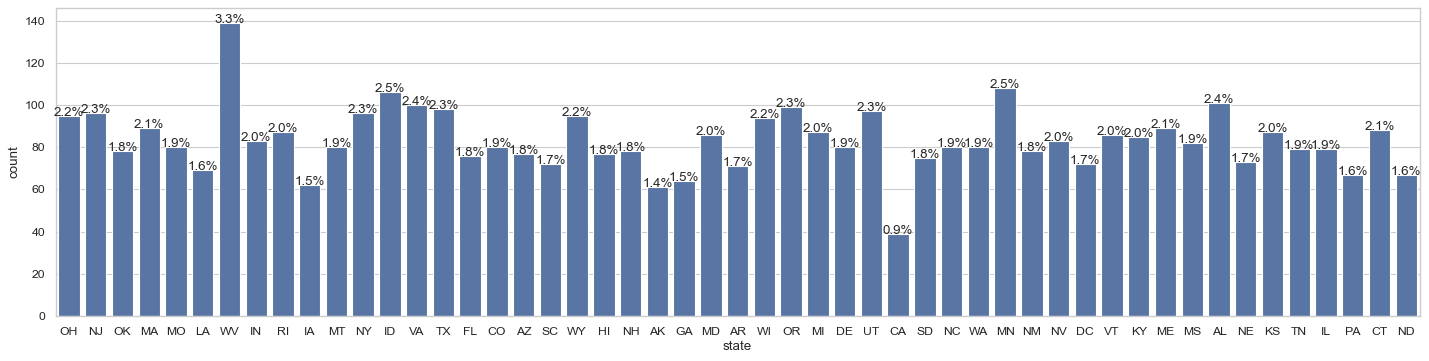

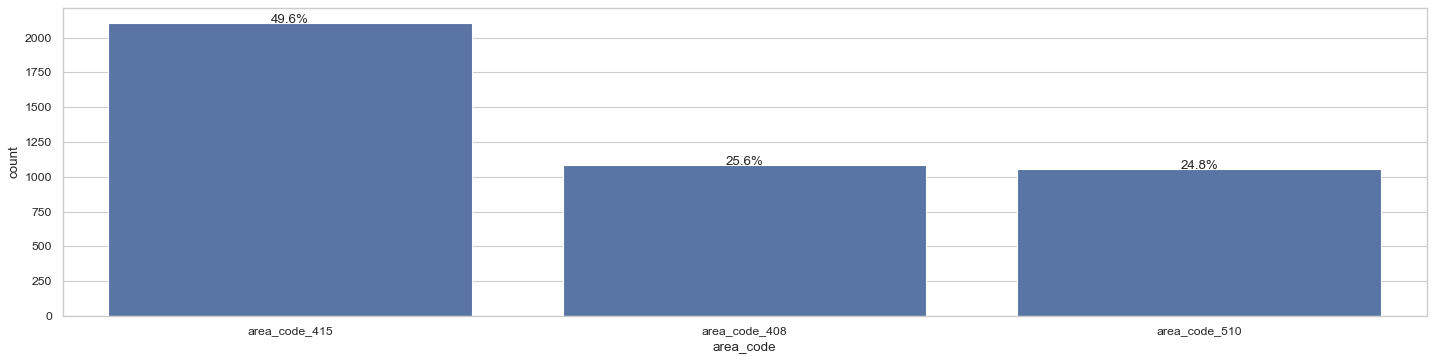

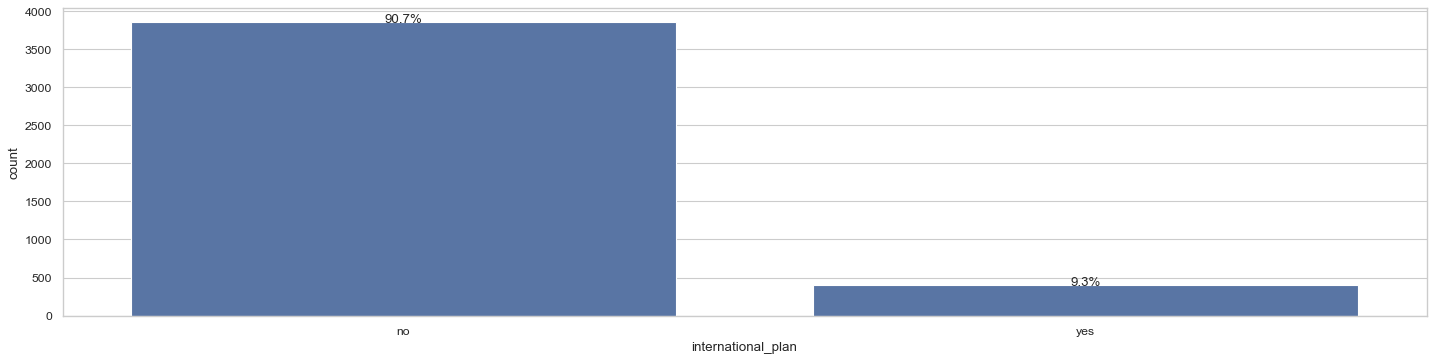

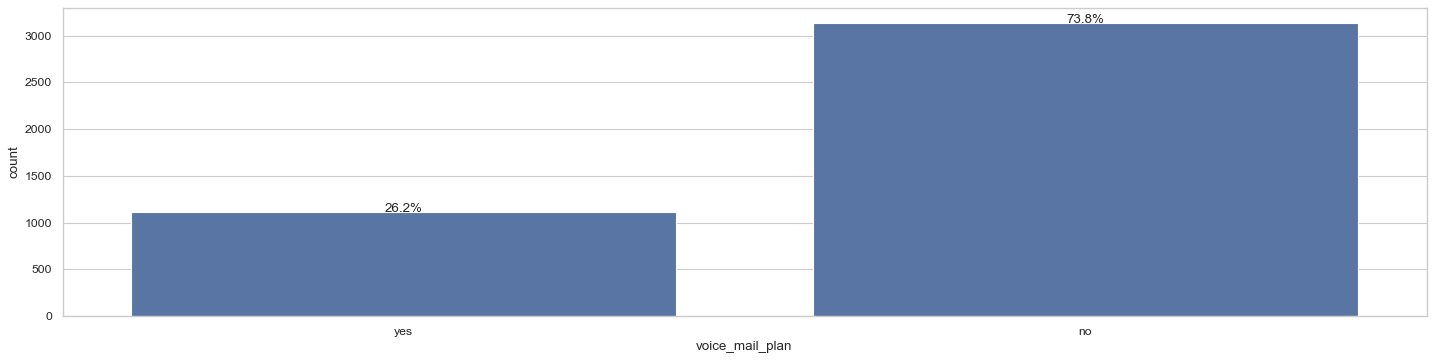

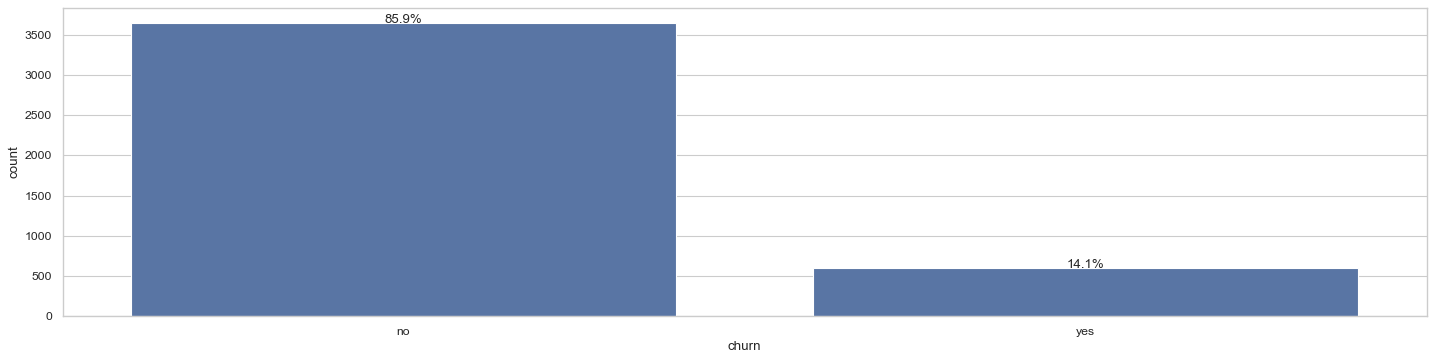

In [40]:
# Построение графиков доли для каждой категориальной переменной с помощью приведенной выше функции:-
for feature in categorical_variables:
    sns.set(style="whitegrid");
    plt.figure(figsize=(22,5), dpi=80);
    total=len(train);
    ax=sns.countplot(x=train[feature], data=train);
    calculate_percentage(total, ax);
    plt.show();

In [41]:
# Из приведенных выше графиков видно, что:-
 # У 90,7% клиентов нет международного тарифного плана
 # У 73,8% клиентов нет тарифного плана голосовой почты
 # 49,6% клиентов остаются с кодом города 415
 # Только 14,1% клиентов уходят от компании


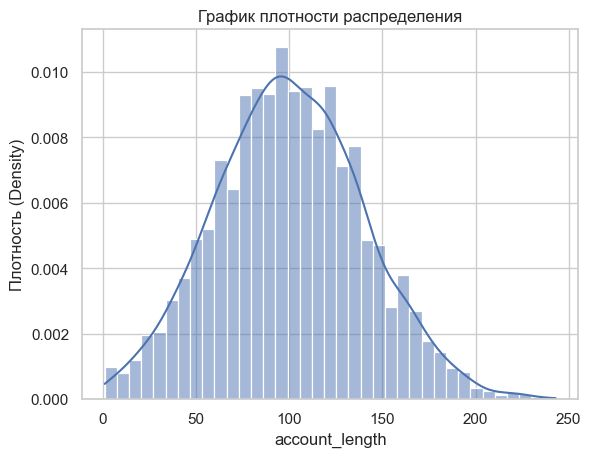

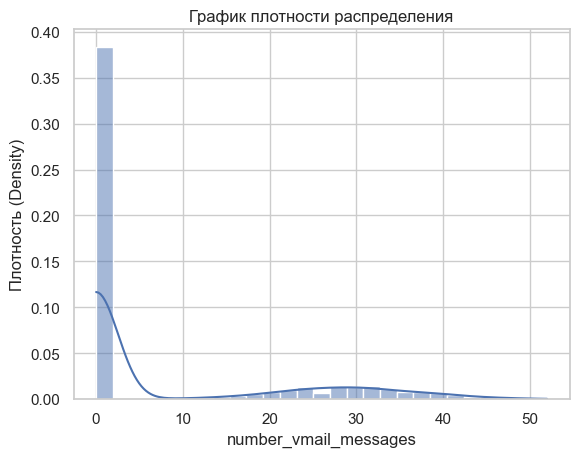

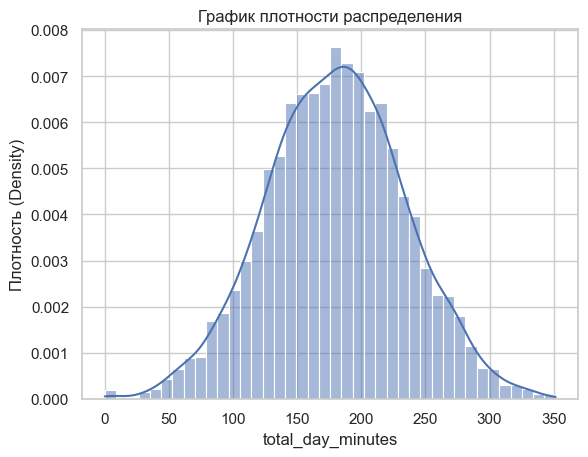

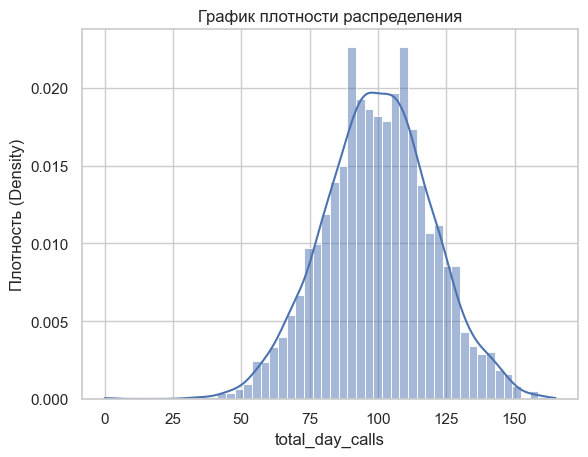

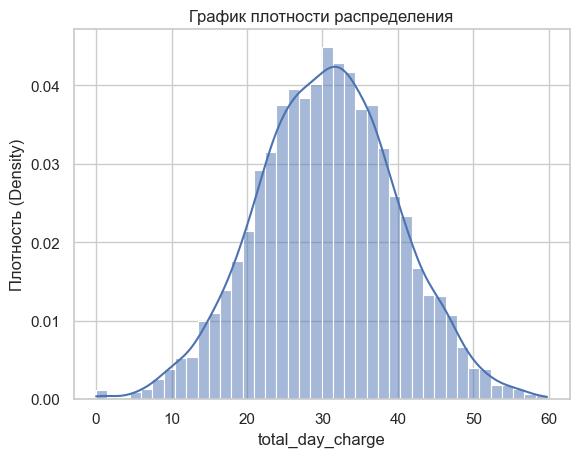

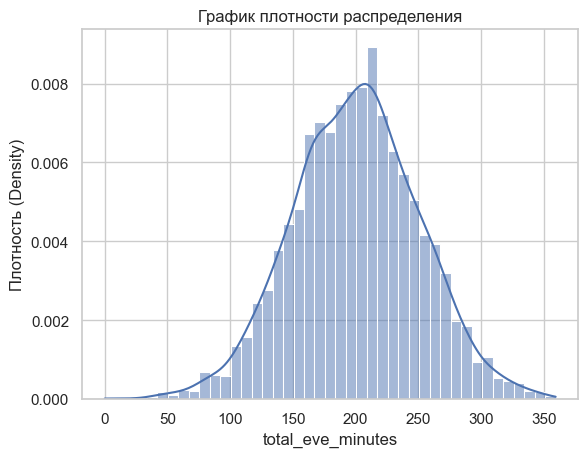

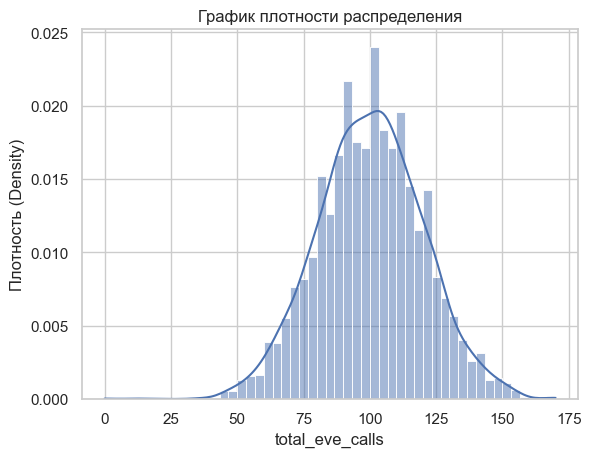

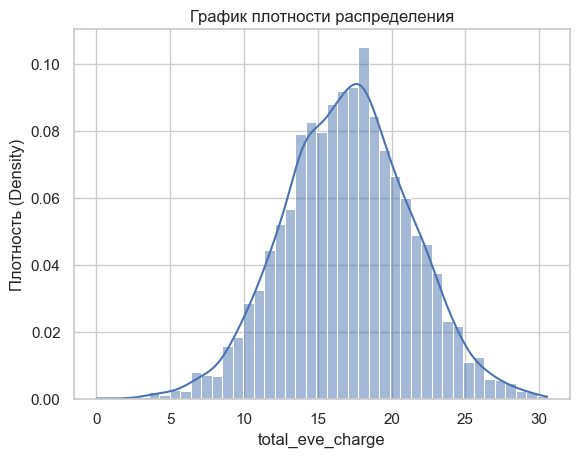

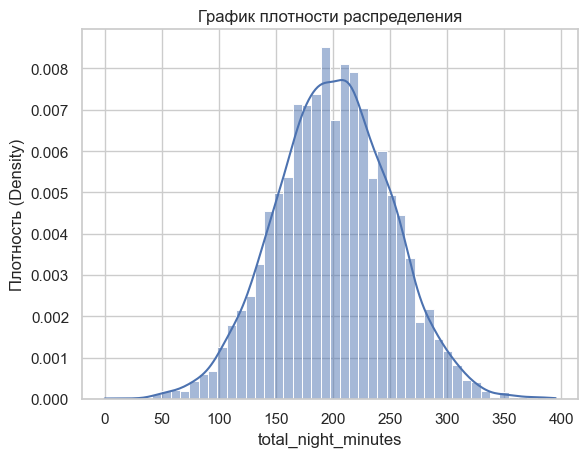

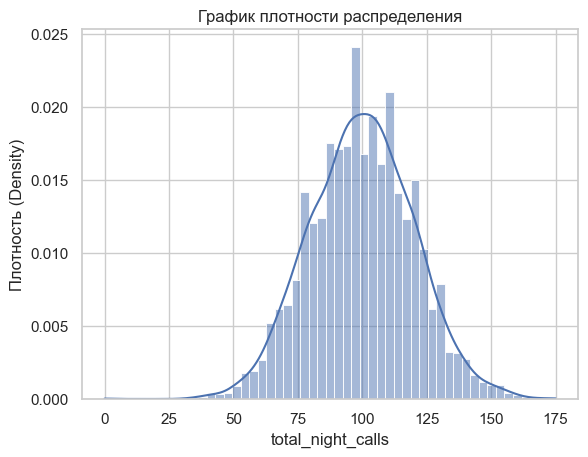

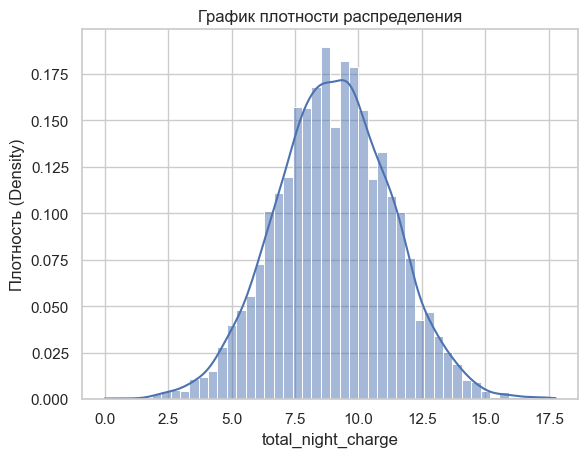

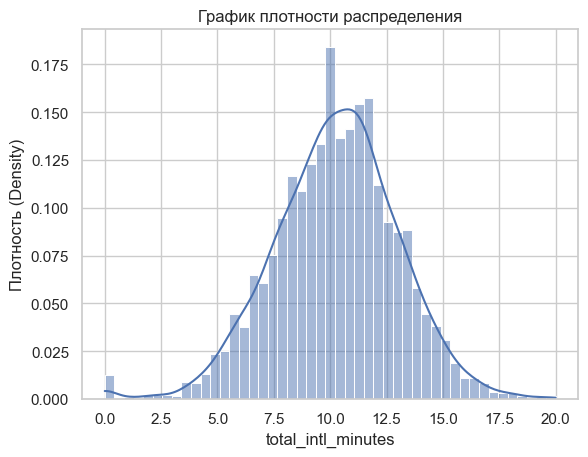

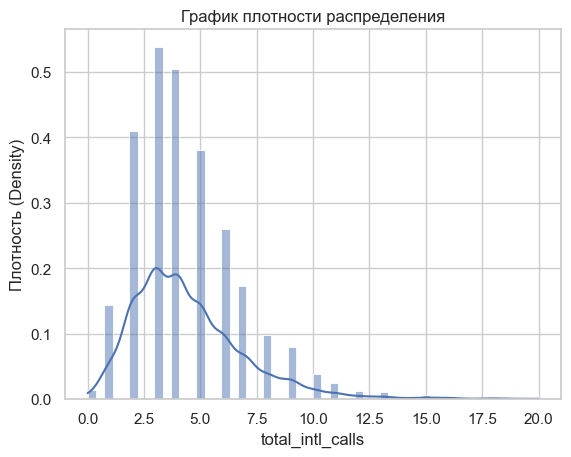

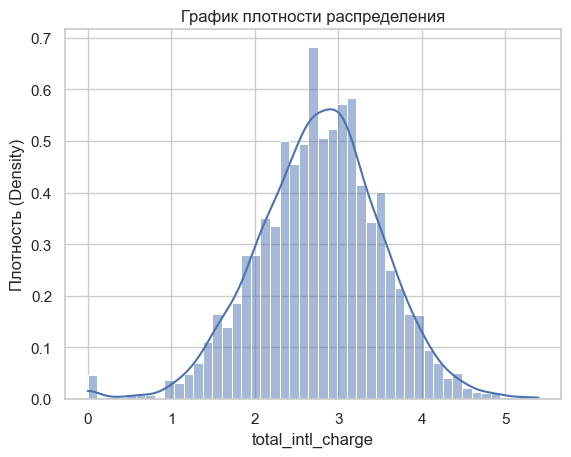

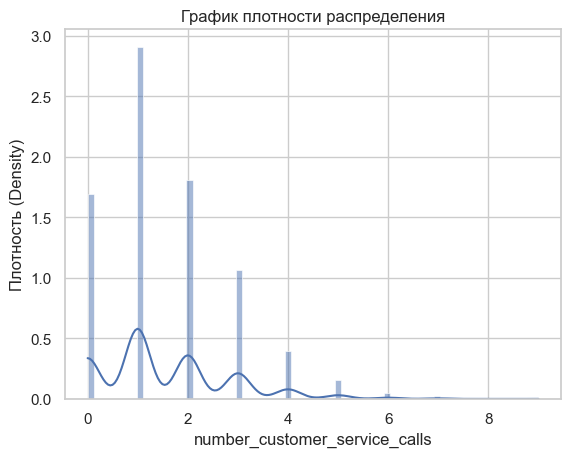

In [42]:
## Числовые переменные ##:-
# Создадим выборку всех числовых признаков
numerical_variables=[]
numerical_variables=[feature for feature in train.columns if train[feature].dtype!="O"];

# Построение графиков плотности для каждой числовой переменной :

for feature in numerical_variables:
    # sns.distplot(train[feature]);
    sns.histplot(train[feature], kde=True, stat="density");
    plt.xlabel(feature);
    plt.ylabel("Плотность (Density)");
    plt.title("График плотности распределения");
    plt.show();

# справка о построении таких графиков см. https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

Из приведенных выше графиков ясно, что:
 - Несколько признаков(столбцов) имеют смещенное среднее, т.е. они не имеют стандартного нормального распределения
 - эти признаки должны быть приведены к стандартному нормальному распределению. 

Такие признаки, как number_customer_service_calls, total_intl_calls и number_vmail_messages, не имеют
нормальное распределение.

#### Двумерный анализ
Двумерный анализ — одна из простейших форм количественного анализа. Он включает в себя анализ двух переменных с целью определения эмпирической связи между ними

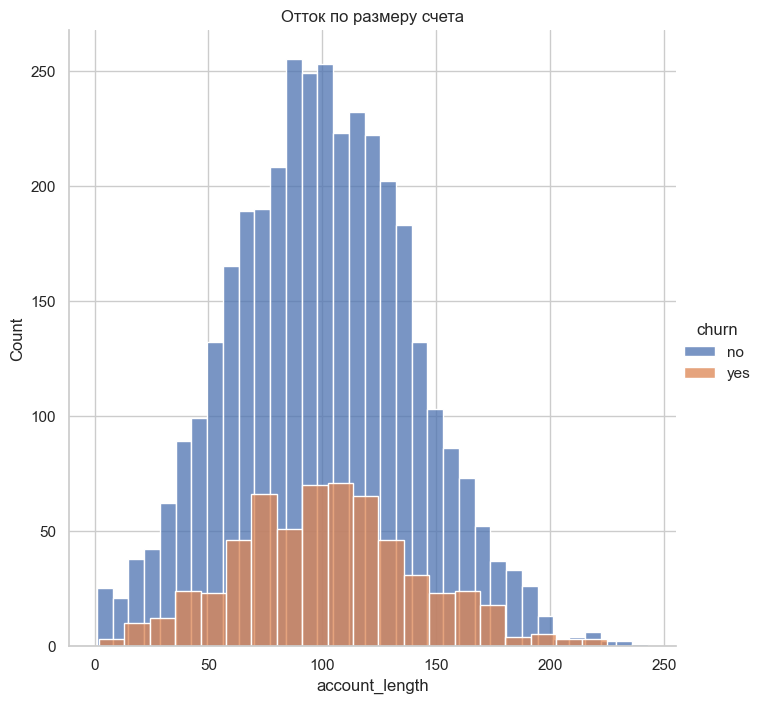

In [43]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "account_length").add_legend();
plt.title("Отток по размеру счета")
plt.show()

Из приведенного выше графика видно, что если "Размер счета" составляет от 90 до 110, уровень оттока наиболее высок.

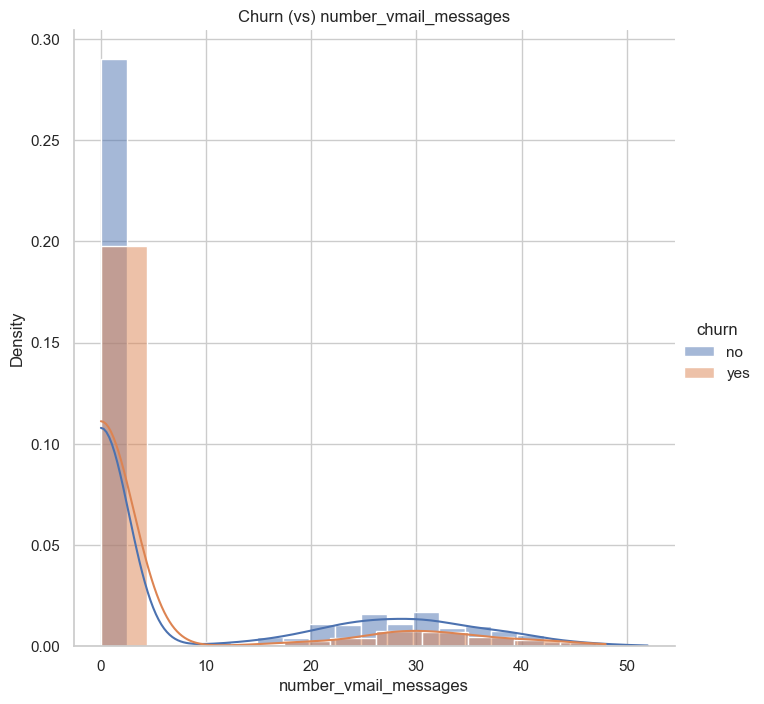

In [44]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "number_vmail_messages", kde=True, stat="density").add_legend();
plt.title("Churn (vs) number_vmail_messages");
plt.show();

Из приведенного выше графика видно, что если "Количество сообщений голосовой почты" ("Number of voice mail messages") равно 0, то уровень оттока очень высок.

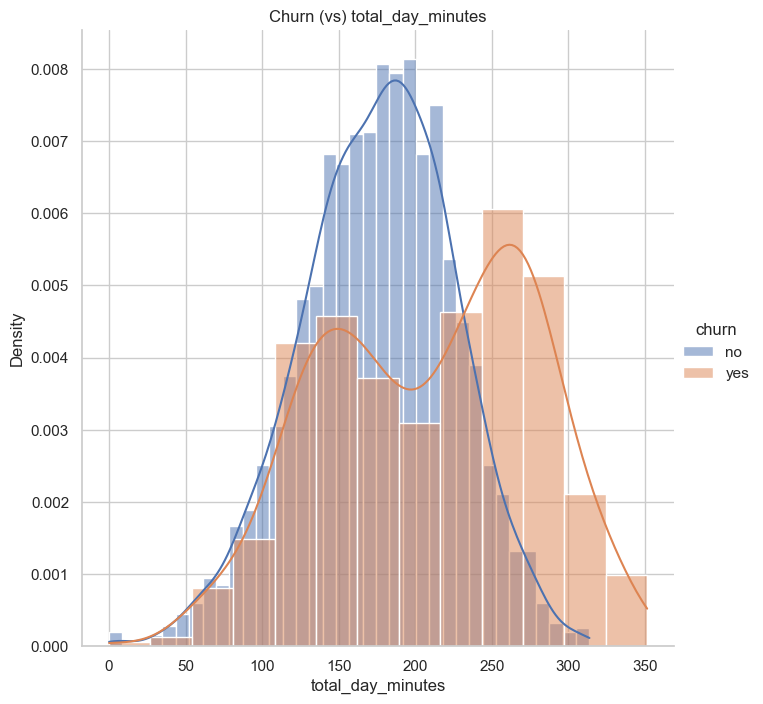

In [45]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_day_minutes", kde=True, stat="density").add_legend();
plt.title("Churn (vs) total_day_minutes");
plt.show();

Из приведенного выше видно, что если "Общее количество минут в дневное время" ("The total day minutes") составляет от 220 до 300 минут, то уровень оттока наиболее высок.

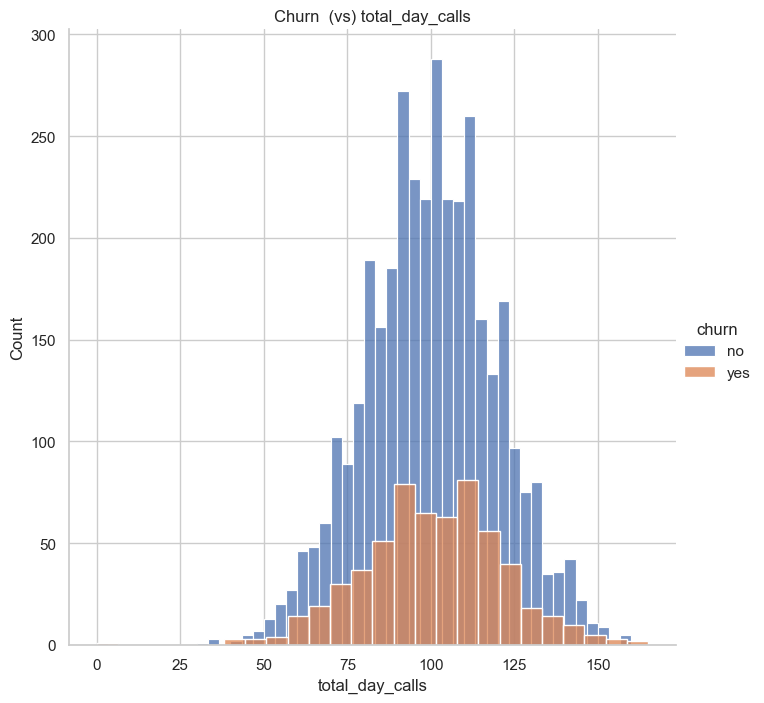

In [46]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_day_calls").add_legend();
plt.title("Churn  (vs) total_day_calls");
plt.show();


Высокий отток наблюдается если "The total day calls" между 85 и 115

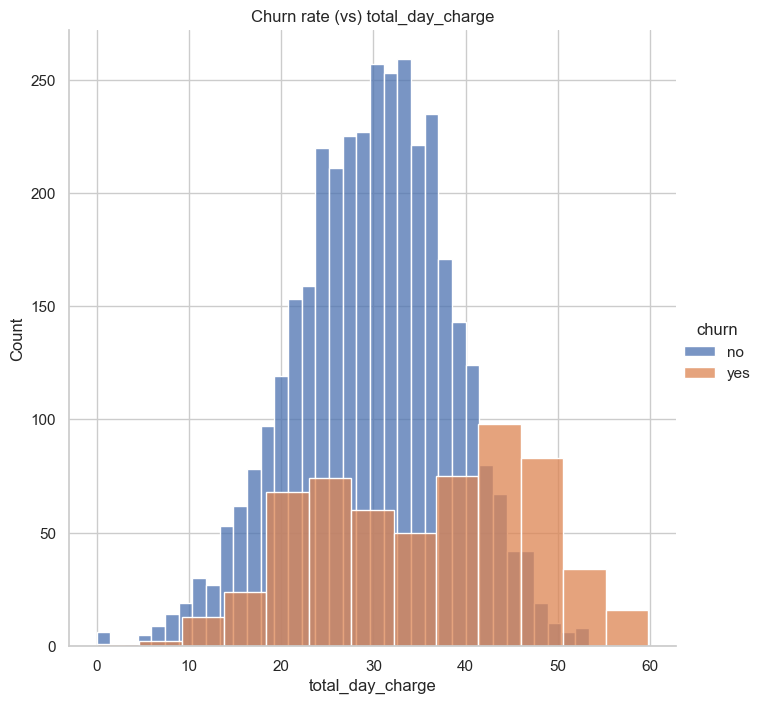

In [47]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_day_charge").add_legend();
plt.title("Churn rate (vs) total_day_charge");
plt.show();

Высокий отток наблюдается если "The total day charges" между 42 и 48

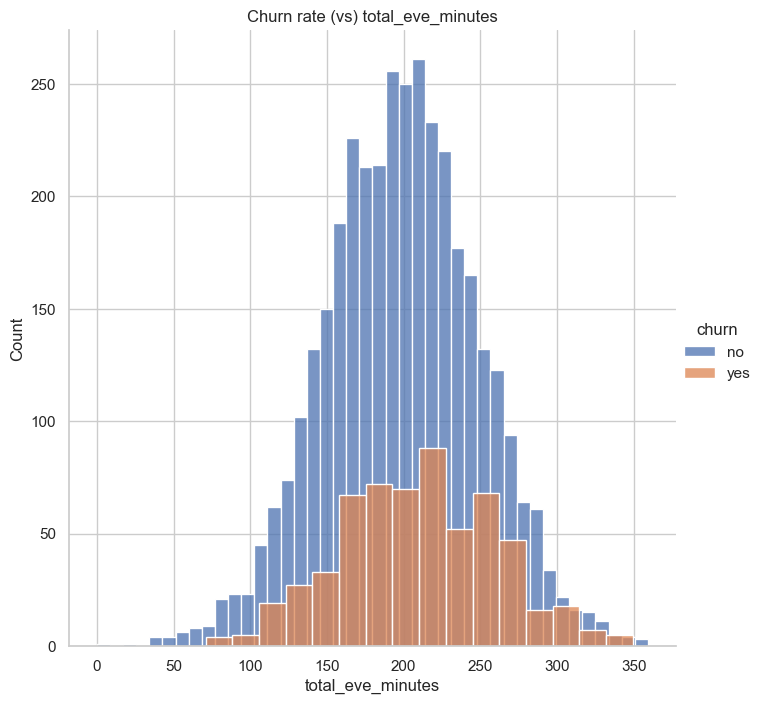

In [48]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_eve_minutes").add_legend();
plt.title("Churn rate (vs) total_eve_minutes");
plt.show();


Высокий отток наблюдается при "The total evening minutes" от 200 до 250

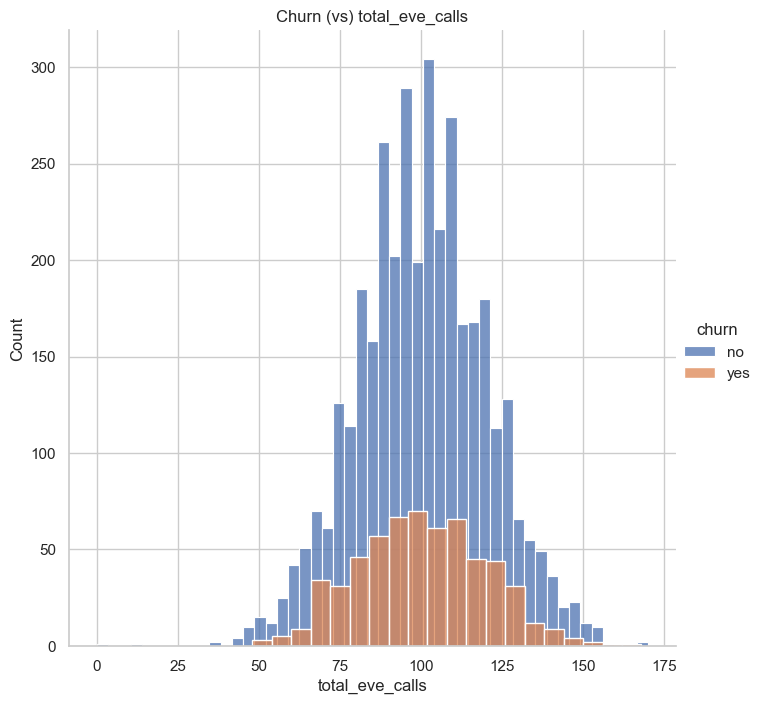

In [49]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_eve_calls").add_legend();
plt.title("Churn (vs) total_eve_calls");
plt.show();


Высокий отток наблюдается при "The total evening calls" около 100


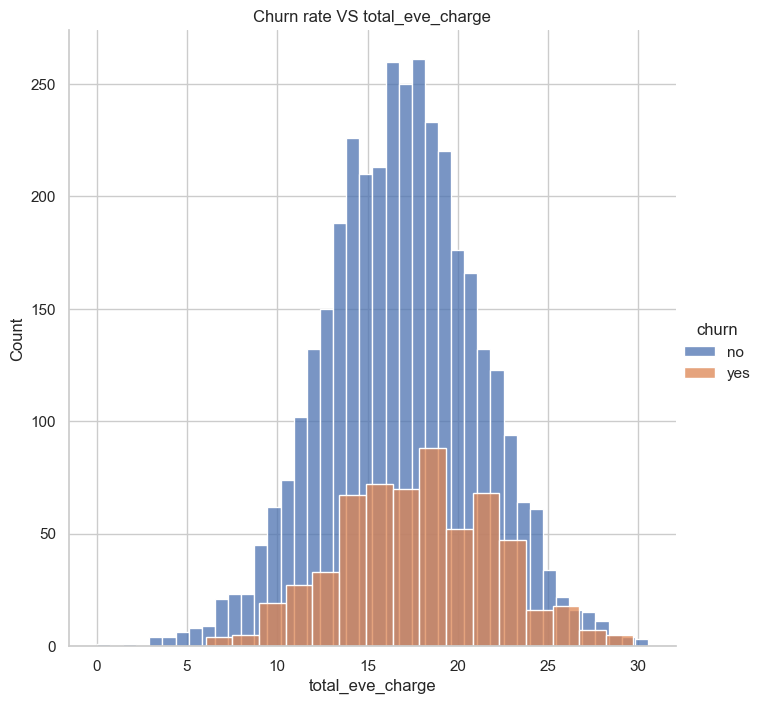

In [50]:
sns.FacetGrid(train, hue='churn',height=7).map(sns.histplot, 'total_eve_charge').add_legend()
plt.title('Churn rate VS total_eve_charge')
plt.show()


Высокий отток наблюдается при "The total evening charges" от 17 до 22


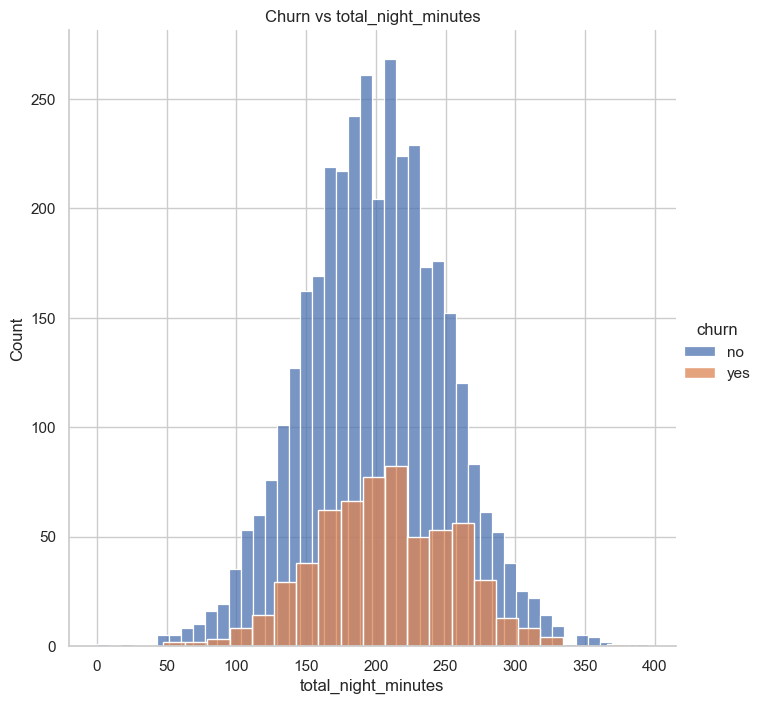

In [51]:
sns.FacetGrid(train, hue='churn',height=7).map(sns.histplot, 'total_night_minutes').add_legend()
plt.title('Churn vs total_night_minutes')
plt.show()

In [52]:
# Высокий отток наблюдается при  "The total night minutes" от 180 до 220 


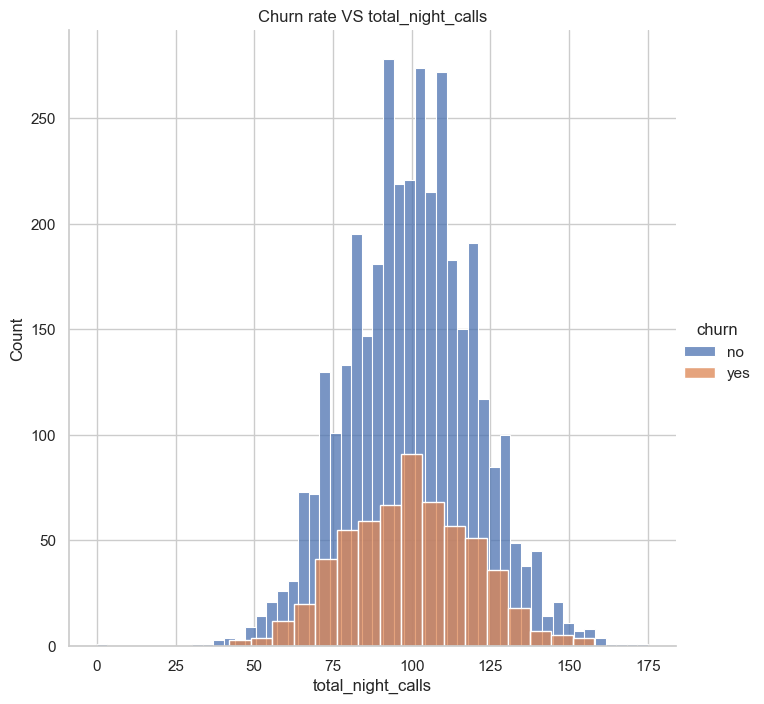

In [53]:
sns.FacetGrid(train, hue='churn',height=7).map(sns.histplot, 'total_night_calls').add_legend()
plt.title('Churn rate VS total_night_calls')
plt.show()

In [54]:
# Высокий отток наблюдается при "The total night calls" от 90 до 110 


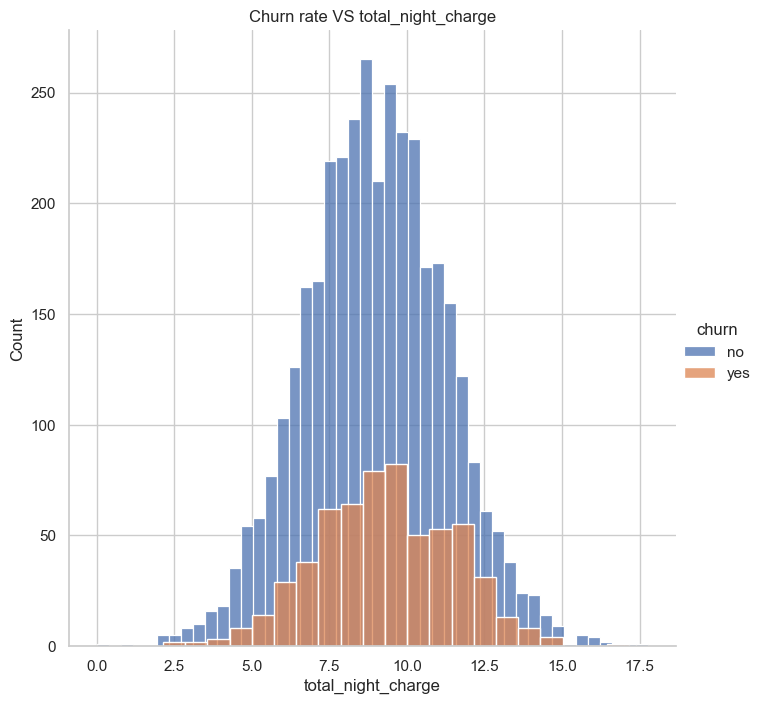

In [55]:
sns.FacetGrid(train, hue='churn',height=7).map(sns.histplot, 'total_night_charge').add_legend()
plt.title('Churn rate VS total_night_charge')
plt.show()


In [56]:
# Высокий отток наблюдается при "The total night charges" между 8 и 11


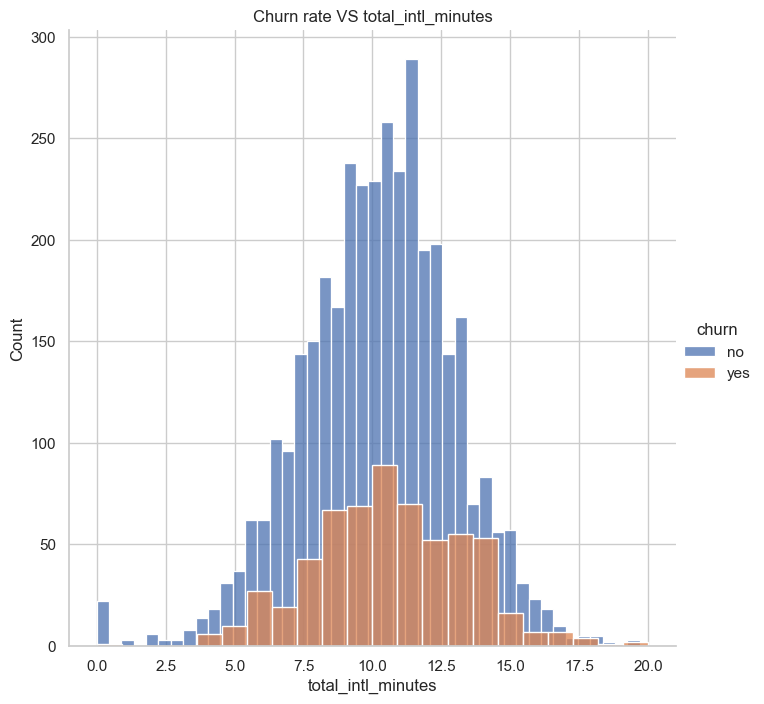

In [57]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_intl_minutes").add_legend()
plt.title("Churn rate VS total_intl_minutes");
plt.show();

In [58]:
# Высокий отток наблюдается при "The total international minutes"  8 < 12


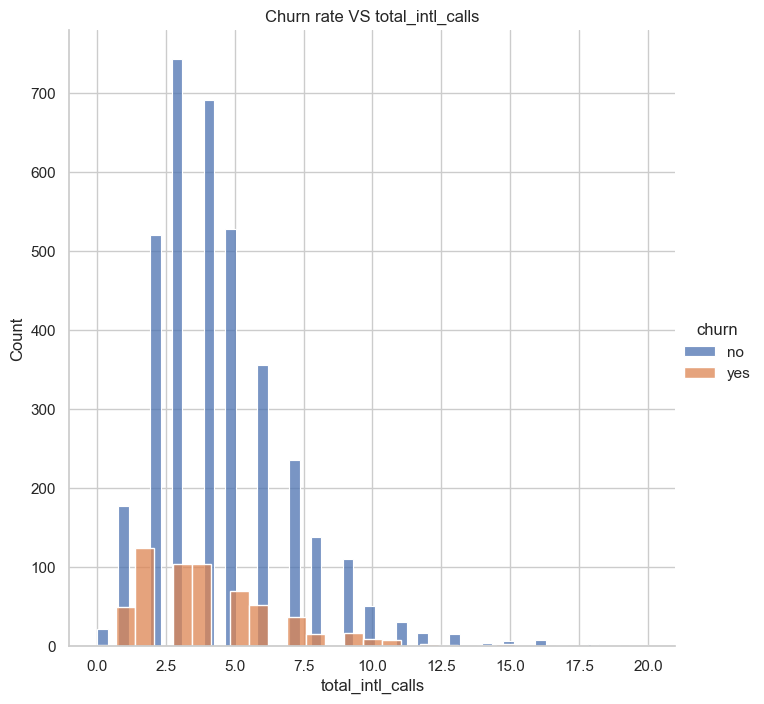

In [59]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_intl_calls").add_legend();
plt.title("Churn rate VS total_intl_calls");
plt.show();

In [60]:
# Высокий отток наблюдается при "The total international calls"  2 < 4 


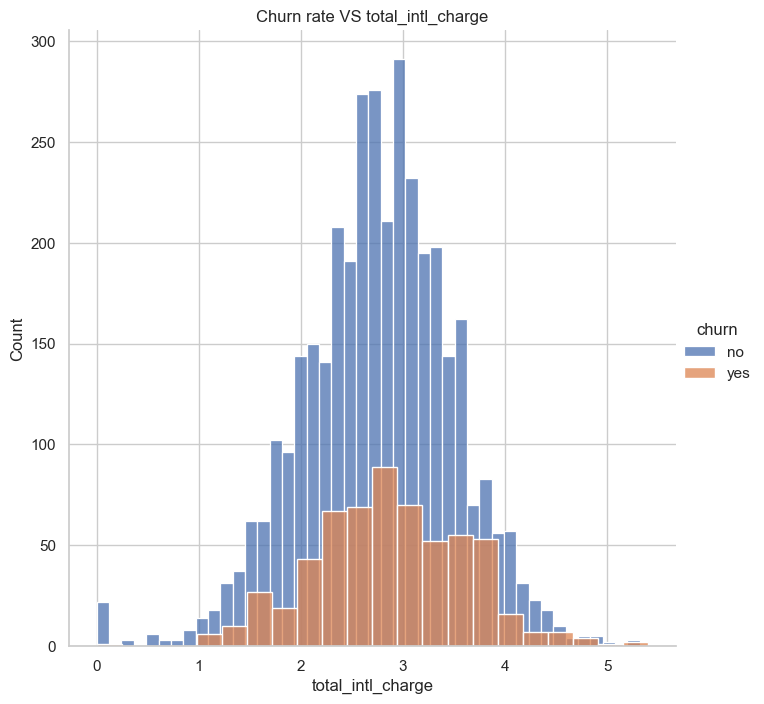

In [61]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "total_intl_charge").add_legend();
plt.title("Churn rate VS total_intl_charge");
plt.show();

In [62]:
# Высокий отток наблюдается при "The total international charge"  2.5 < 3


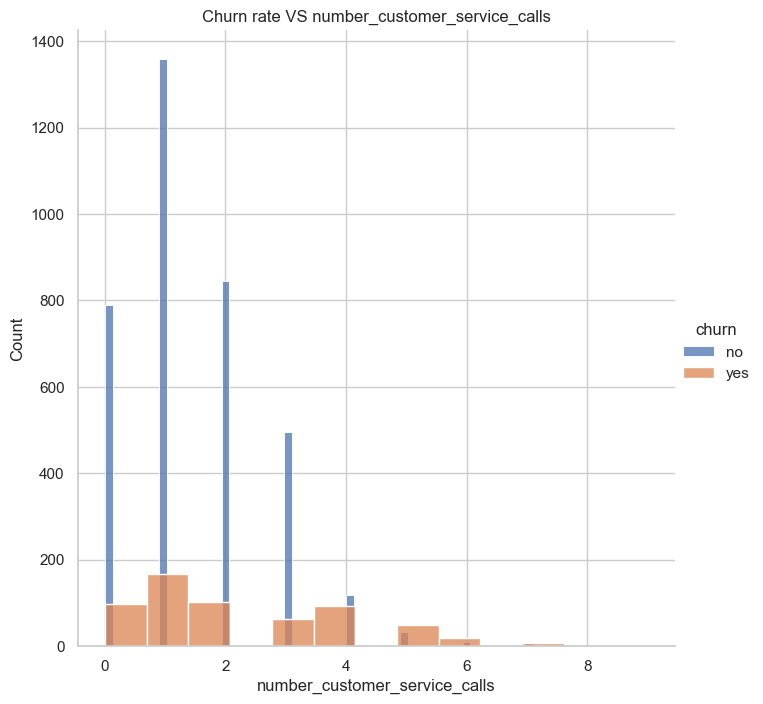

In [63]:
sns.FacetGrid(train, hue="churn", height=7).map(sns.histplot, "number_customer_service_calls").add_legend();
plt.title("Churn rate VS number_customer_service_calls");
plt.show();


In [64]:
# Высокий отток наблюдается при "The number of customer service calls" = 1 


### Анализ выбросов

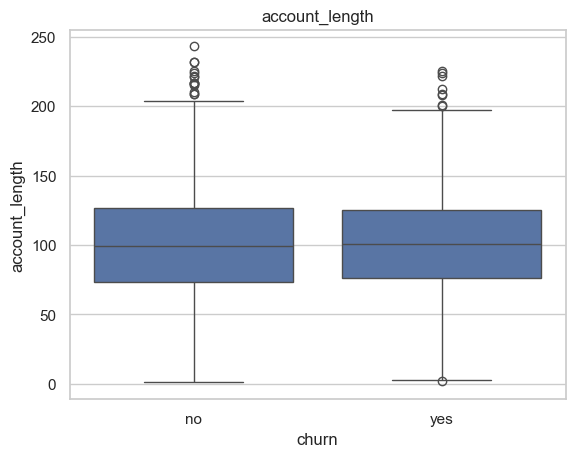

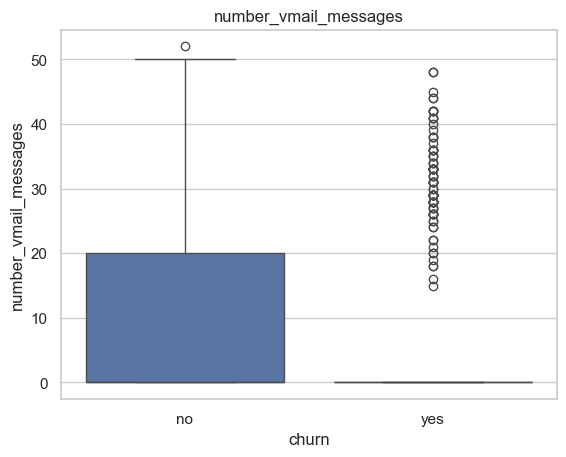

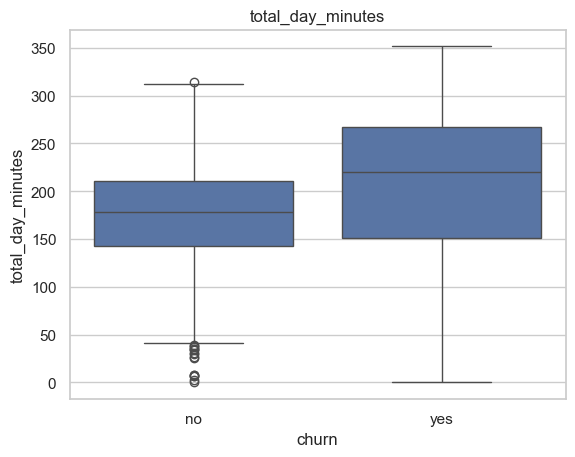

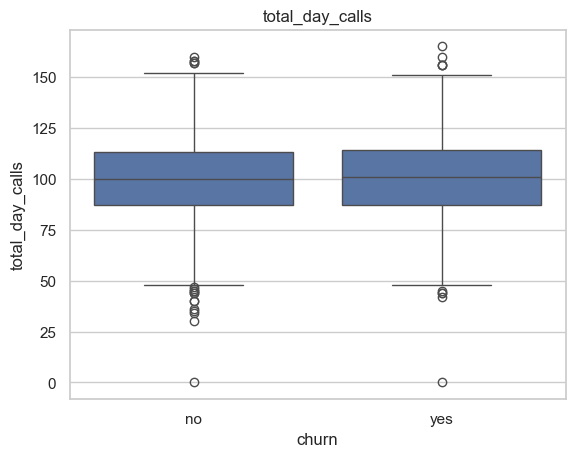

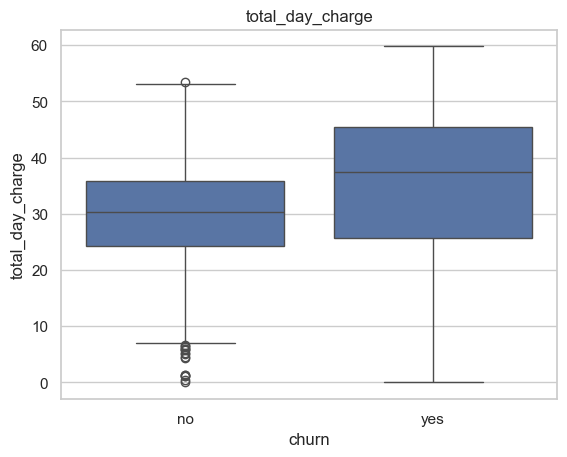

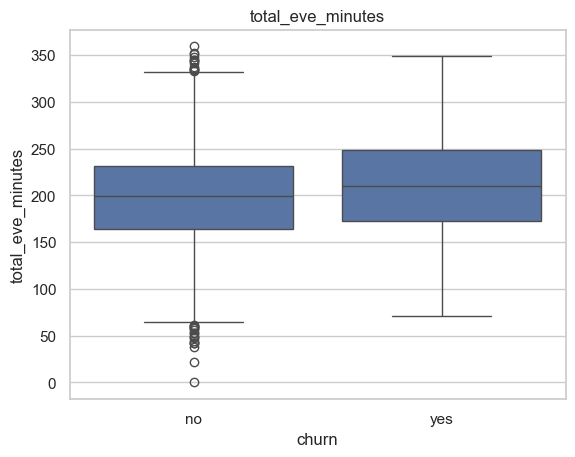

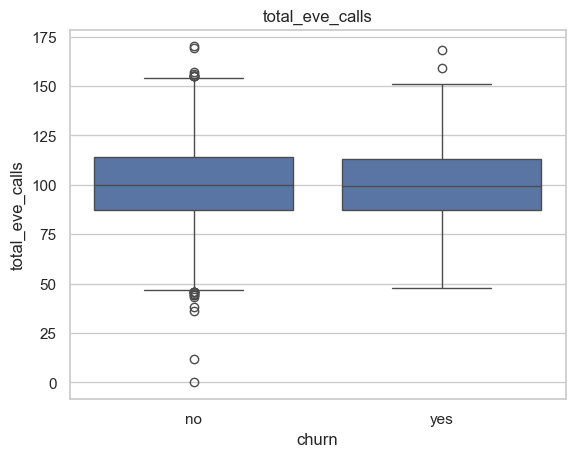

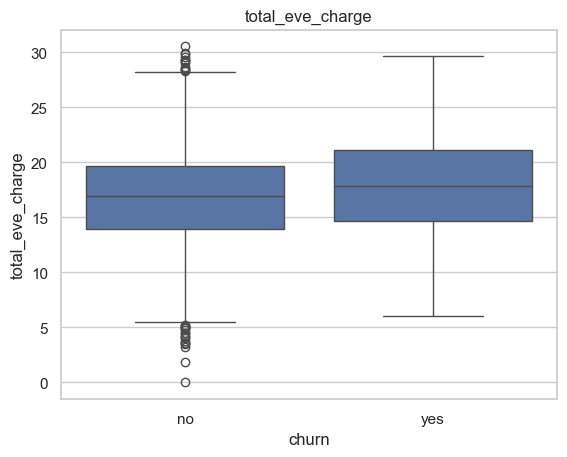

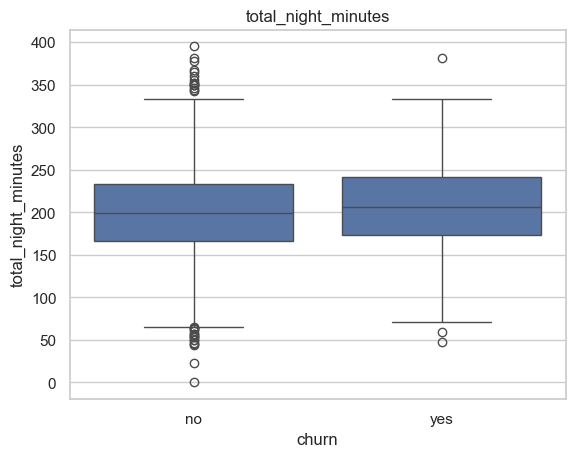

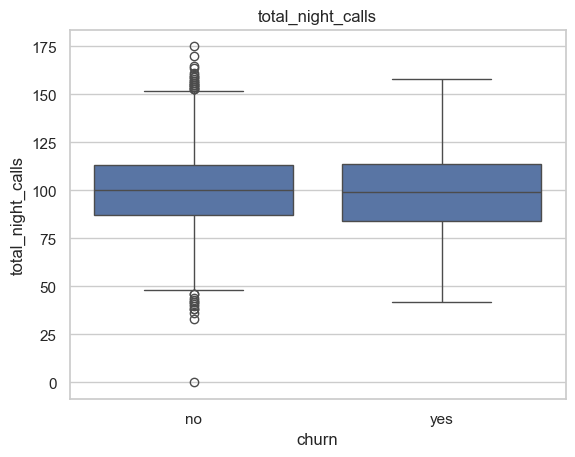

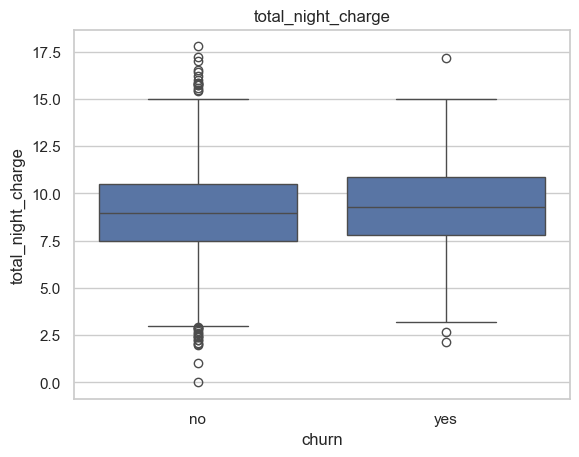

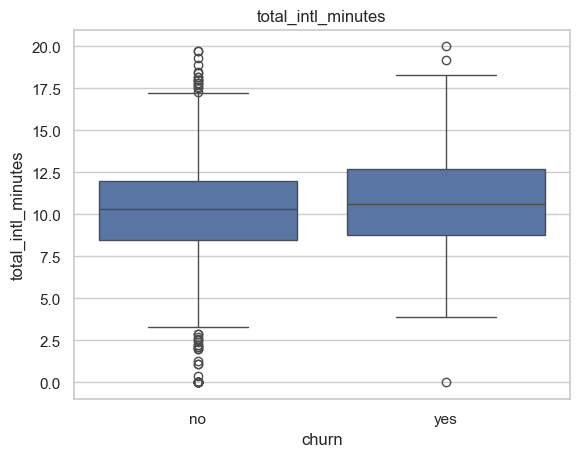

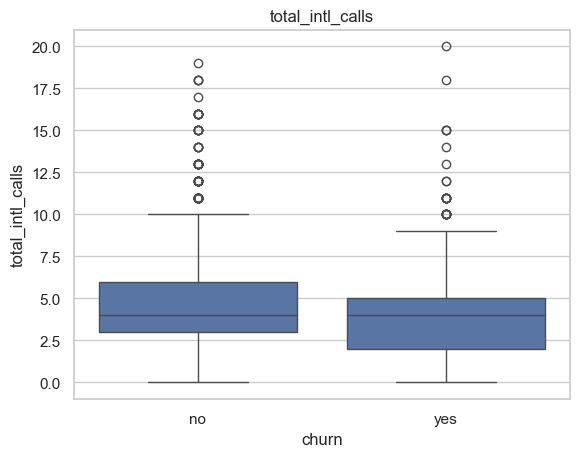

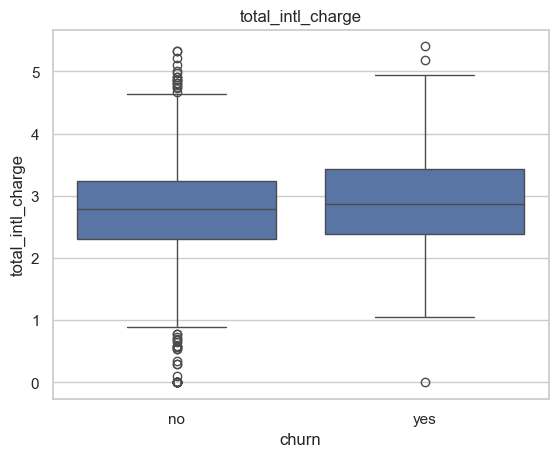

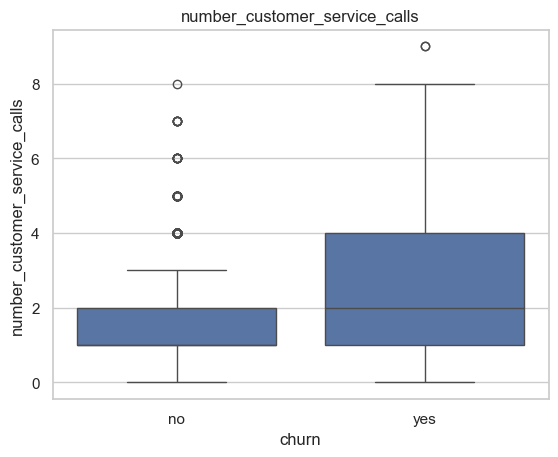

In [65]:
## Числовые характеристики ##:
# был использован seaborn, т.к. он дает лучшую визуализацию, чем pandas :

for feature in numerical_variables:
    sns.boxplot(x="churn", y=feature, data=train);
    plt.title(feature);
    plt.show();

Из приведенного выше ясно, что каждый признак содержит выбросы, нам нужно эти выбросы удалить
 

In [66]:
# Заменяем выбросы их медианой и сохраняем их в новом датафрейме:-
def eliminate_outliers(df, labels):
    for feature in labels:
        quantile1=df[feature].quantile(0.25)
        quantile2=df[feature].quantile(0.75)
        
        iqr=quantile2 - quantile1
        upper_bound=quantile2 + 1.5*iqr
        lower_bound=quantile1 - 1.5*iqr
        
        df[feature]=df[feature].mask(df[feature]<lower_bound, df[feature].median(), axis=0)
        df[feature]=df[feature].mask(df[feature]>upper_bound, df[feature].median(), axis=0)
        
    return df

train_eliminate_outliers=eliminate_outliers(train, numerical_variables)


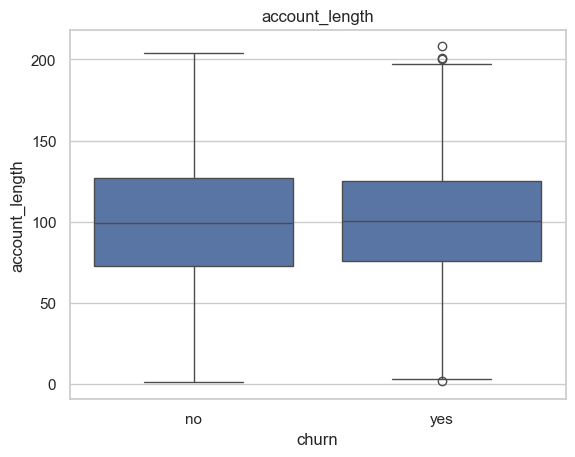

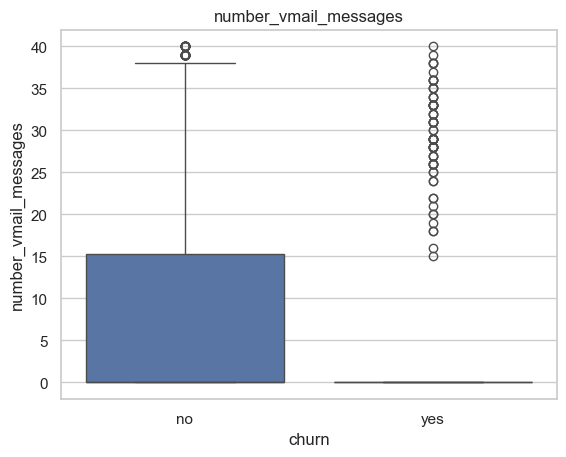

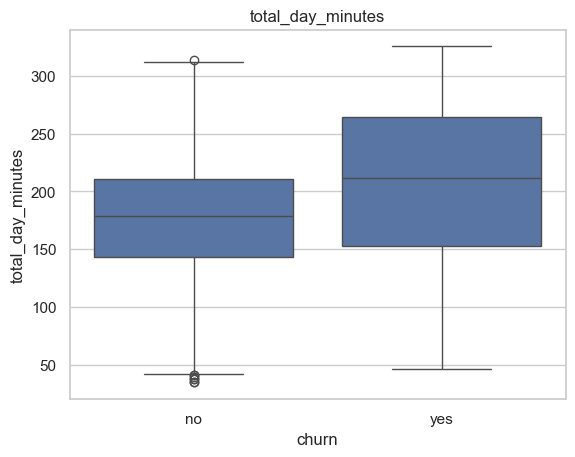

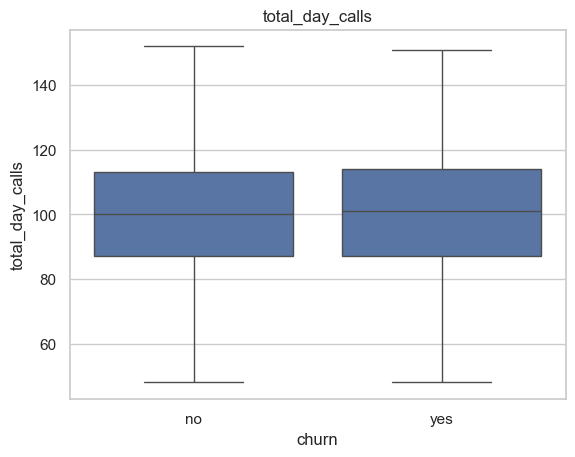

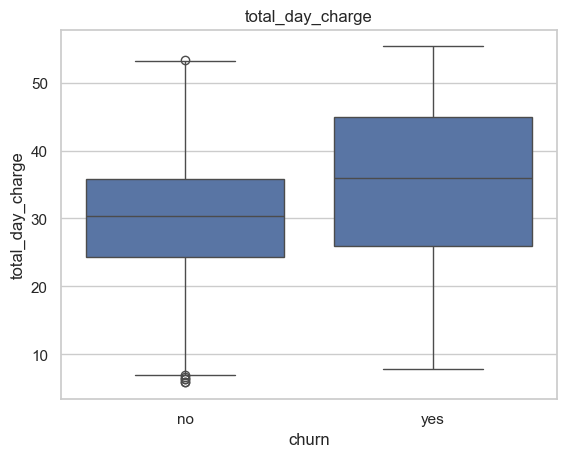

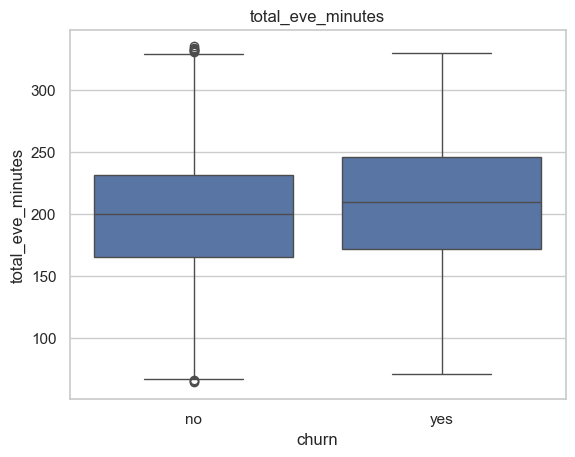

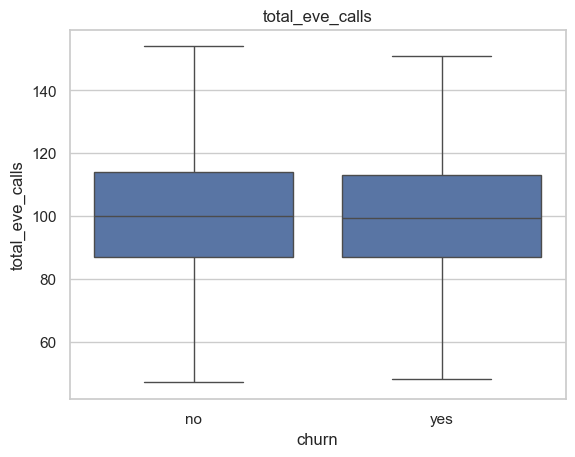

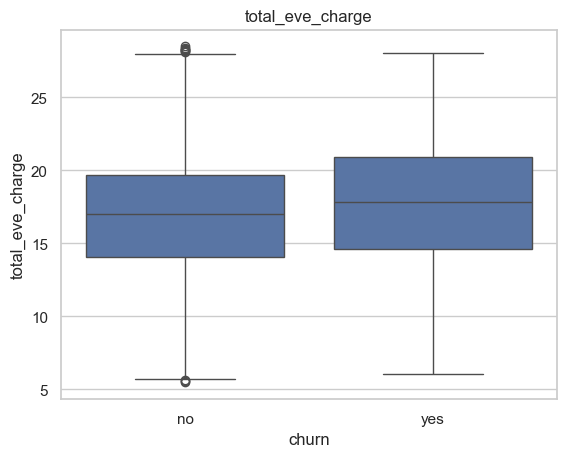

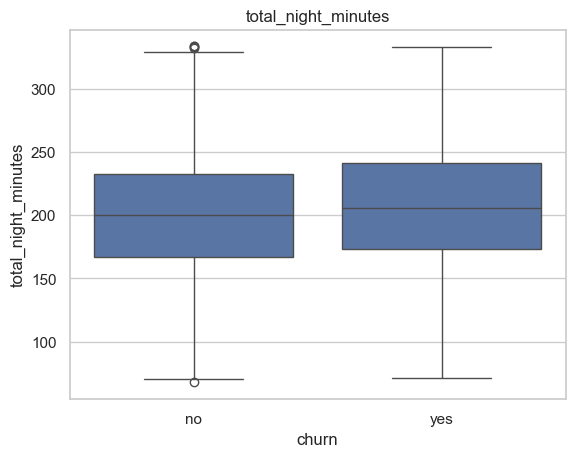

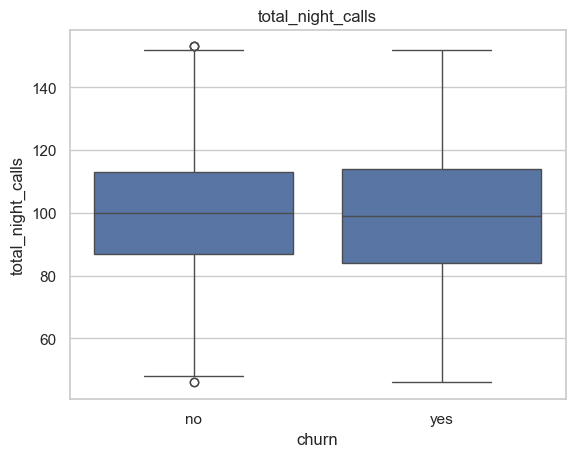

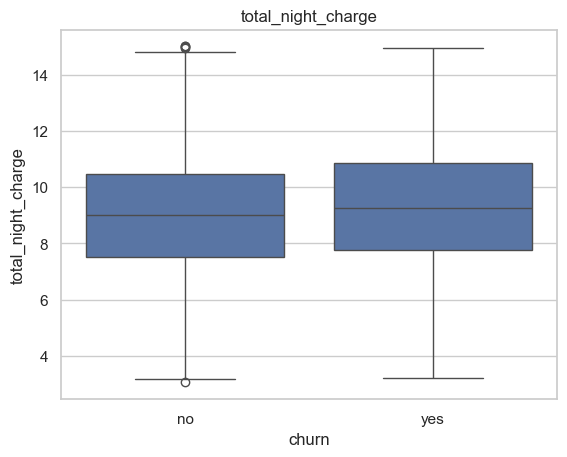

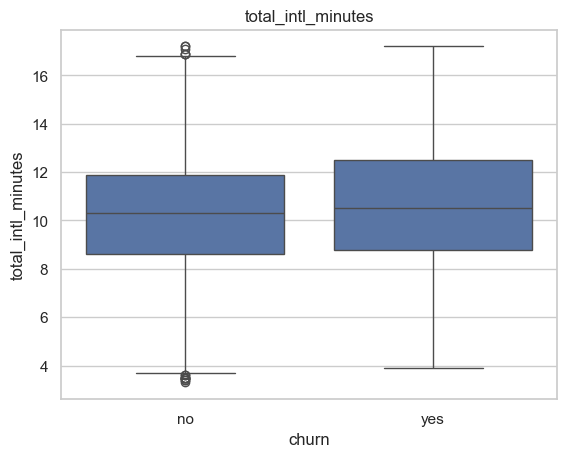

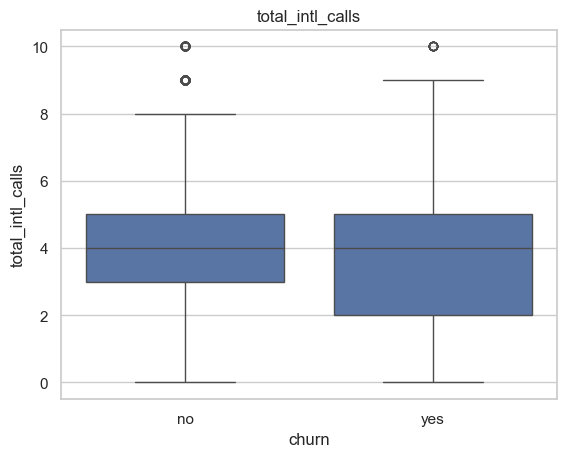

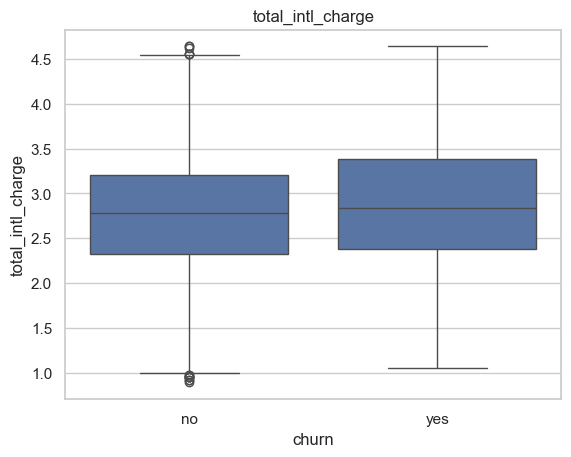

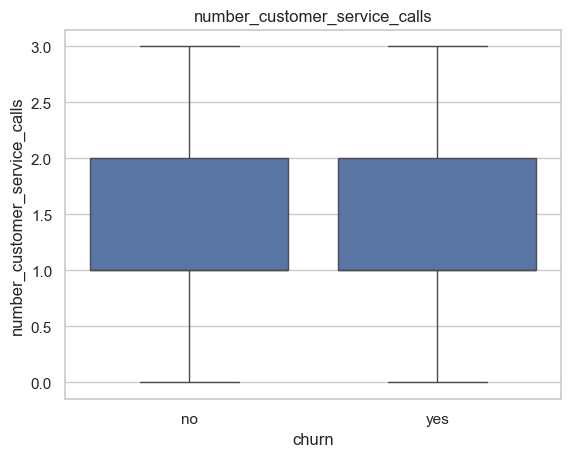

In [67]:
#графики "Ящик с усами" после удаления выбросов

for feature in numerical_variables:
    sns.boxplot(x="churn", y=feature, data=train_eliminate_outliers)
    plt.title(feature)
    plt.show()

In [68]:
#### Обработка категориальных признаков ####

# # функция unique() используется для нахождения количества различных значений в столбце:
train_eliminate_outliers["state"].nunique()

51

In [69]:
# Из приведенного выше видно, что признак state имеет 51 различное значение.
 
 # Таким образом, если реализовать кодировщик One Hot Encoder для признака state, то он создает 51 различный признак, и есть угроза
 # переобучения, т.е. категориальные данные могут представлять серьезную проблему, если они имеют слишком много уникальных
 # значений.
 
 # Поэтому для преодоления этой проблемы используется кодировщик Hash Encoder.
  # (https://www.analyticsvidhya.com/blog/2020/08/types-of-categorical-data-encoding/)


In [70]:
hash_object=ce.HashingEncoder(cols="state")

train_hash=hash_object.fit_transform(train_eliminate_outliers);
test_hash=hash_object.fit_transform(test);

train_hash.head() # 


,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,account_length,area_code,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,0,0,0,0,1,0,0,0,107,area_code_415,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
1,0,1,0,0,0,0,0,0,137,area_code_415,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
2,0,0,0,0,1,0,0,0,84,area_code_408,...,88,17.06,196.9,89,8.86,6.6,7,1.78,2,no
3,0,0,0,0,1,0,0,0,75,area_code_415,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no
4,0,0,0,0,1,0,0,0,121,area_code_510,...,108,17.06,212.6,118,9.57,7.5,7,2.03,3,no


In [71]:
#Замена "No" на 0 и "Yes" на 1 для значений категориальных признаков:

train_hash.international_plan.replace(["no", "yes"], [0, 1], inplace=True);
train_hash.voice_mail_plan.replace(["no", "yes"], [0, 1], inplace=True);
train_hash.churn.replace(["no", "yes"], [0, 1], inplace=True);

test_hash.international_plan.replace(["no", "yes"], [0, 1], inplace=True);
test_hash.voice_mail_plan.replace(["no", "yes"], [0, 1], inplace=True);

train_hash.head();

/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/2616579715.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_hash.international_plan.replace(["no", "yes"], [0, 1], inplace=True);
/var/folders/4d/lm1ncz4930jcqtlb3wc_f9040000gn/T/ipykernel_50283/2616579715.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.n

In [72]:
print(train_hash["churn"])

0       0
1       0
2       0
3       0
4       0
       ..
4245    0
4246    0
4247    0
4248    0
4249    0
Name: churn, Length: 4250, dtype: int64


In [73]:
## признак area_code имеет тип "Object",поэтому его надо конвертировать в "Numerical"

train_hash=pd.get_dummies(train_hash, columns=["area_code"]);
train_hash.info();


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   col_0                          4250 non-null   int64  
 1   col_1                          4250 non-null   int64  
 2   col_2                          4250 non-null   int64  
 3   col_3                          4250 non-null   int64  
 4   col_4                          4250 non-null   int64  
 5   col_5                          4250 non-null   int64  
 6   col_6                          4250 non-null   int64  
 7   col_7                          4250 non-null   int64  
 8   account_length                 4250 non-null   int64  
 9   international_plan             4250 non-null   int64  
 10  voice_mail_plan                4250 non-null   int64  
 11  number_vmail_messages          4250 non-null   int64  
 12  total_day_minutes              4250 non-null   f

In [74]:
test_hash=pd.get_dummies(test_hash, columns=["area_code"]);
test_hash.info();
# Признак area_code был преобразован в целочисленный тип из object type для тестовых данных.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   col_0                          750 non-null    int64  
 1   col_1                          750 non-null    int64  
 2   col_2                          750 non-null    int64  
 3   col_3                          750 non-null    int64  
 4   col_4                          750 non-null    int64  
 5   col_5                          750 non-null    int64  
 6   col_6                          750 non-null    int64  
 7   col_7                          750 non-null    int64  
 8   id                             750 non-null    int64  
 9   account_length                 750 non-null    int64  
 10  international_plan             750 non-null    int64  
 11  voice_mail_plan                750 non-null    int64  
 12  number_vmail_messages          750 non-null    int

## Теперь обработаем набор данных с несбалансированными классами

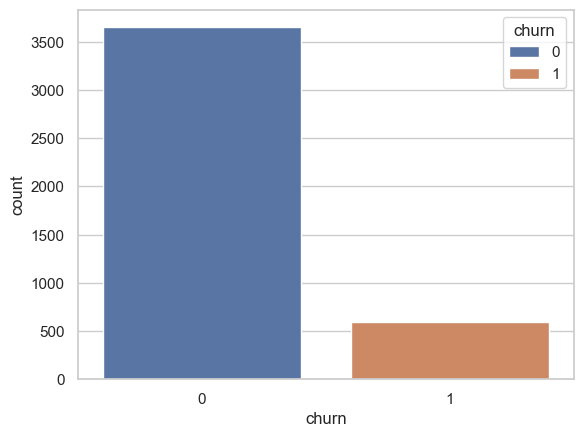

In [75]:
sns.countplot(x="churn", data=train_hash, hue="churn");
plt.show()
# 0 -> No Churn, 1 -> Churn

In [76]:
x=train_hash.drop("churn", axis=1).values
y=train_hash.churn.values

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.3, random_state=0);

In [77]:
y_train

array([0, 1, 1, ..., 0, 0, 0])

In [78]:
print("Исходный размер класса 0 {}".format(sum(y_train==0)));
print("Исходный размер класса 1 {}".format(sum(y_train==1)));

Исходный размер класса 0 2550
Исходный размер класса 1 425


In [79]:
## Увеличиваем размер выборки меньшего класса, т.е. класса 1 -> Применяется только к обучающему набору ##
 # Synthetic Minority Oversampling Technique (SMOTE) #
# https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

sm=SMOTE(sampling_strategy=1);
x_train_smote, y_train_smote=sm.fit_resample(x_train, y_train);

print("После увеличения размера выборки класса 0 {}".format(sum(y_train_smote==0))); # class 0
print("После увеличения размера выборки класса 1 {}".format(sum(y_train_smote==1))); # class 1


После увеличения размера выборки класса 0 2550
После увеличения размера выборки класса 1 2550


/Users/bereznevn/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [80]:
# Масштабируем датасет 

scaler=MinMaxScaler();
x_train_smote_scale=scaler.fit_transform(x_train_smote);
x_test_scale=scaler.fit_transform(x_test);


Классическое Машинное обучение

In [81]:
#Случайный лес - RandomForest Classifier #
rfc=RandomForestClassifier(n_jobs=-1);
rfc.fit(x_train_smote_scale, y_train_smote);

print(accuracy_score(y_test, rfc.predict(x_test_scale)));
# 91.5% 


0.9129411764705883


In [82]:
test=rfc.predict(x_test_scale);

In [83]:
print(classification_report(y_test, test));

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1102
           1       0.79      0.49      0.60       173

    accuracy                           0.91      1275
   macro avg       0.86      0.74      0.78      1275
weighted avg       0.91      0.91      0.90      1275



Из приведенного выше видно, что значение точности для 2-го набора данных намного лучше, чем для 1-го набора данных.

# Нейронная сеть

In [84]:


model=Sequential()

# написать свою архитектуру и обучить сеть



In [85]:
test = [round(x[0]) for x in model.predict(x_test_scale)];
print(accuracy_score(y_test, test));

ValueError: Sequential model sequential_2 cannot be built because it has no layers. Call `model.add(layer)`.

 ## Задание 2.
 Провести анализ влияния гиперпараметров на качество модели.
 
 1. Кол-во эпох 
 2. Размер партии (батча)
 3. Разные методы инициализации весов (напр., HeNormal)
 4. Изменить архитектуру. Добиться качества, лучше RandomForest



In [ ]:
# Кривые AUC (и) ROC:-
test_fpr, test_tpr, test_thresholds = roc_curve(y_test, test);
test_roc_auc=auc(test_fpr, test_tpr);

plt.figure(figsize=(7,5), dpi=80);
plt.plot(test_fpr, test_tpr, color="red",label='ROC кривая на train (area = %0.4f)' % test_roc_auc);
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0]);
plt.ylim([0.0, 1.0]);
plt.xlabel("False Positive Rate (FPR)", fontsize=14);
plt.ylabel("True Positive Rate (TPR)", fontsize=14);
plt.title("ROC кривая", fontsize=16);
plt.show();